<a href="https://colab.research.google.com/github/Sai-Vara-Prasad-Lekkalapudi/major-project/blob/main/Sai_Major_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Project Topic:
Financial Feature Optimization for Corporate Bankruptcy Prediction using Gradient Boosting Models.

##Dataset: https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data
##Research question:
Which financial indicators are most influential in predicting corporate bankruptcy, and how does feature selection affect model performance
##Goal:
My aim is to identify the most important financial features influencing bankruptcy prediction and to understand how feature selection and dimensionality reduction affect both accuracy and interpretability of machine learning models.


# Importing Libraries & Configuration

In [ ]:
!pip install catboost

# Core Libraries

import pandas as pd
import numpy as np

# Data Loading

from scipy.io import arff

import urllib.request
from scipy.io import arff

# Preprocessing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE


# Imbalanced Data Handling

from imblearn.over_sampling import SMOTE


# Models

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV

# Evaluation Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc


# Visualization

import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Configuration

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 5)


# Ignore warnings for clean output
import warnings
warnings.filterwarnings("ignore")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.1 MB/s eta 0:00:00


#  Loading Polish Companies Bankruptcy ARFF Datasets from GitHub

In [ ]:

# Loading Polish Companies Bankruptcy ARFF Datasets

# GitHub ARFF file URLs (1year–5year)

github_arff_urls = [
    'https://raw.githubusercontent.com/Sai-Vara-Prasad-Lekkalapudi/major-project/refs/heads/main/1year.arff',
    'https://raw.githubusercontent.com/Sai-Vara-Prasad-Lekkalapudi/major-project/refs/heads/main/2year.arff',
    'https://raw.githubusercontent.com/Sai-Vara-Prasad-Lekkalapudi/major-project/refs/heads/main/3year.arff',
    'https://raw.githubusercontent.com/Sai-Vara-Prasad-Lekkalapudi/major-project/refs/heads/main/4year.arff',
    'https://raw.githubusercontent.com/Sai-Vara-Prasad-Lekkalapudi/major-project/refs/heads/main/5year.arff'
]


# Function Definition

def load_bankruptcy_datasets_from_github(urls, save_dir="/content"):
    """
    Downloading Polish Companies Bankruptcy ARFF files from GitHub,
    loads them into pandas DataFrames, and returns them as a dictionary.

    Parameters:
    urls : list
        List of GitHub raw URLs pointing to ARFF files (1year–5year).
    save_dir : str, optional
        Local directory where ARFF files will be temporarily stored.

    Returns:
    dict
        Dictionary where keys are dataset names (e.g., '1year', '2year')
        and values are pandas DataFrames containing company financial ratios.
    """

    bankruptcy_datasets = {}

    for url in urls:
        # Extracting dataset name
        dataset_year = url.split("/")[-1].split(".")[0]
        local_file_path = f"{save_dir}/{dataset_year}.arff"

        # Downloading ARFF file
        urllib.request.urlretrieve(url, local_file_path)

        # Loading ARFF file
        companies_data, metadata = arff.loadarff(local_file_path)
        companies_df = pd.DataFrame(companies_data)

        # Converting target variable to integer
        companies_df["class"] = companies_df["class"].astype(int)

        # Storing dataset
        bankruptcy_datasets[dataset_year] = companies_df

        # Displaying dataset summary
        print(f"\nLoaded {dataset_year} bankruptcy dataset")
        print(f"Shape: {companies_df.shape}")
        print(companies_df.info())

    return bankruptcy_datasets


# Function Call

bankruptcy_datasets = load_bankruptcy_datasets_from_github(github_arff_urls)



Loaded 1year bankruptcy dataset
Shape: (7027, 65)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7027 entries, 0 to 7026
Data columns (total 65 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Attr1   7024 non-null   float64
 1   Attr2   7024 non-null   float64
 2   Attr3   7024 non-null   float64
 3   Attr4   6997 non-null   float64
 4   Attr5   7019 non-null   float64
 5   Attr6   7024 non-null   float64
 6   Attr7   7024 non-null   float64
 7   Attr8   7002 non-null   float64
 8   Attr9   7026 non-null   float64
 9   Attr10  7024 non-null   float64
 10  Attr11  6988 non-null   float64
 11  Attr12  6997 non-null   float64
 12  Attr13  7027 non-null   float64
 13  Attr14  7024 non-null   float64
 14  Attr15  7025 non-null   float64
 15  Attr16  7002 non-null   float64
 16  Attr17  7002 non-null   float64
 17  Attr18  7024 non-null   float64
 18  Attr19  7027 non-null   float64
 19  Attr20  7027 non-null   float64
 20  Attr21  5405 non-null  

# Exploratory Data Analysis (EDA)

In [ ]:
# Basic Data Understanding & Initial EDA


def basic_data_overview(bankruptcy_datasets):
    """
    Performs initial exploratory data analysis (EDA) on bankruptcy datasets.

    This function provides:
     Dataset shape
     Number of features
     Target class distribution
     Percentage of bankrupt vs non-bankrupt firms

    Parameters:
    bankruptcy_datasets : dict
        Dictionary containing datasets for each year
        (keys: '1year' to '5year', values: pandas DataFrames)

    Returns:
    None
        Prints summary statistics for each dataset.
    """

    for year, companies_df in bankruptcy_datasets.items():
        print(f"\n {year.upper()} DATASET OVERVIEW ")

        # Dataset shape
        rows, cols = companies_df.shape
        print(f"Total Records: {rows}")
        print(f"Total Features (including target): {cols}")
        print(f"Financial Ratios: {cols - 1}")

        # Target distribution
        class_counts = companies_df["class"].value_counts().sort_index()
        bankrupt = class_counts.get(1, 0)
        non_bankrupt = class_counts.get(0, 0)

        print("\nTarget Variable Distribution:")
        print(f"Non-Bankrupt (0): {non_bankrupt}")
        print(f"Bankrupt (1): {bankrupt}")

        # Class imbalance percentage
        bankrupt_ratio = (bankrupt / rows) * 100
        print(f"Bankruptcy Rate: {bankrupt_ratio:.2f}%")




# FUNCTION CALL

basic_data_overview(bankruptcy_datasets)



 1YEAR DATASET OVERVIEW 
Total Records: 7027
Total Features (including target): 65
Financial Ratios: 64

Target Variable Distribution:
Non-Bankrupt (0): 6756
Bankrupt (1): 271
Bankruptcy Rate: 3.86%

 2YEAR DATASET OVERVIEW 
Total Records: 10173
Total Features (including target): 65
Financial Ratios: 64

Target Variable Distribution:
Non-Bankrupt (0): 9773
Bankrupt (1): 400
Bankruptcy Rate: 3.93%

 3YEAR DATASET OVERVIEW 
Total Records: 10503
Total Features (including target): 65
Financial Ratios: 64

Target Variable Distribution:
Non-Bankrupt (0): 10008
Bankrupt (1): 495
Bankruptcy Rate: 4.71%

 4YEAR DATASET OVERVIEW 
Total Records: 9792
Total Features (including target): 65
Financial Ratios: 64

Target Variable Distribution:
Non-Bankrupt (0): 9277
Bankrupt (1): 515
Bankruptcy Rate: 5.26%

 5YEAR DATASET OVERVIEW 
Total Records: 5910
Total Features (including target): 65
Financial Ratios: 64

Target Variable Distribution:
Non-Bankrupt (0): 5500
Bankrupt (1): 410
Bankruptcy Rate: 6.9

# Analyzes missing values in each year bankruptcy dataset


 1YEAR MISSING VALUE ANALYSIS 

Total Missing Values: 5835
Percentage Missing: 1.28%

Top Features with Missing Values:
Attr37    2740
Attr21    1622
Attr27     311
Attr60     135
Attr45     134
Attr24     124
Attr41      84
Attr11      39
Attr32      38
Attr54      34
dtype: int64


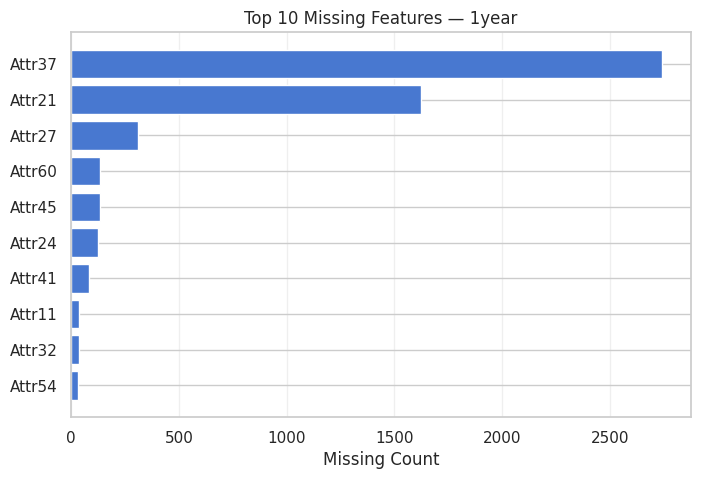


 2YEAR MISSING VALUE ANALYSIS 

Total Missing Values: 12157
Percentage Missing: 1.84%

Top Features with Missing Values:
Attr37    4518
Attr21    3164
Attr27     706
Attr60     543
Attr45     541
Attr24     225
Attr54     212
Attr28     212
Attr64     212
Attr53     212
dtype: int64


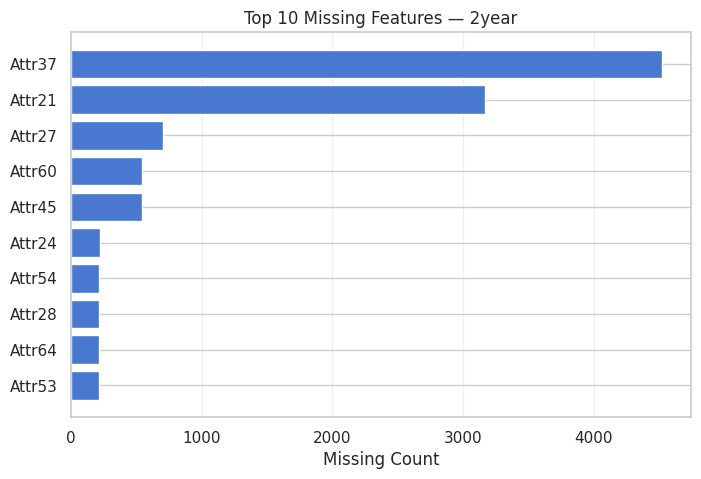


 3YEAR MISSING VALUE ANALYSIS 

Total Missing Values: 9888
Percentage Missing: 1.45%

Top Features with Missing Values:
Attr37    4736
Attr21     807
Attr27     715
Attr60     592
Attr45     591
Attr28     228
Attr54     228
Attr53     228
Attr64     228
Attr24     227
dtype: int64


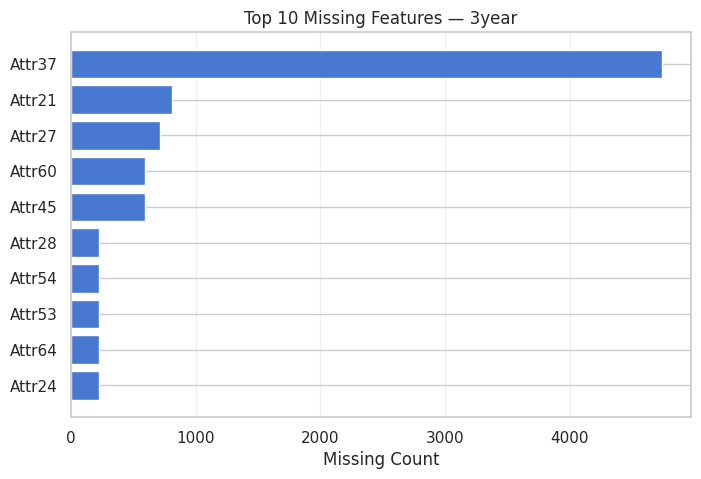


 4YEAR MISSING VALUE ANALYSIS 

Total Missing Values: 8776
Percentage Missing: 1.38%

Top Features with Missing Values:
Attr37    4442
Attr27     641
Attr60     614
Attr45     613
Attr54     231
Attr28     231
Attr64     231
Attr53     231
Attr24     211
Attr41     187
dtype: int64


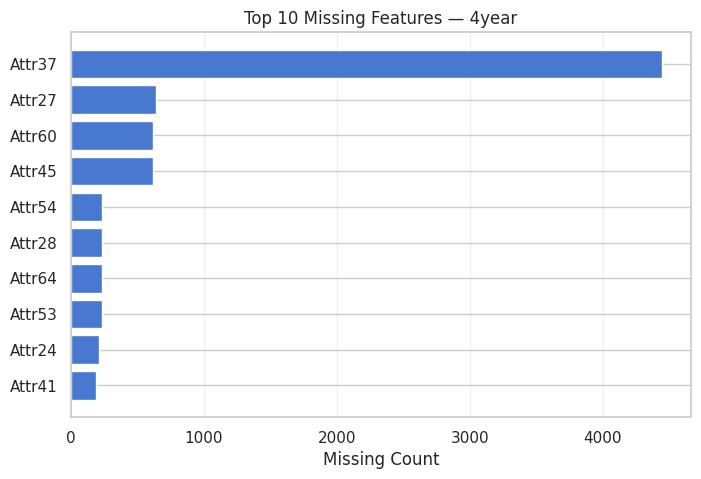


 5YEAR MISSING VALUE ANALYSIS 

Total Missing Values: 4666
Percentage Missing: 1.21%

Top Features with Missing Values:
Attr37    2548
Attr27     391
Attr60     268
Attr45     268
Attr24     135
Attr28     107
Attr64     107
Attr53     107
Attr54     107
Attr21     103
dtype: int64


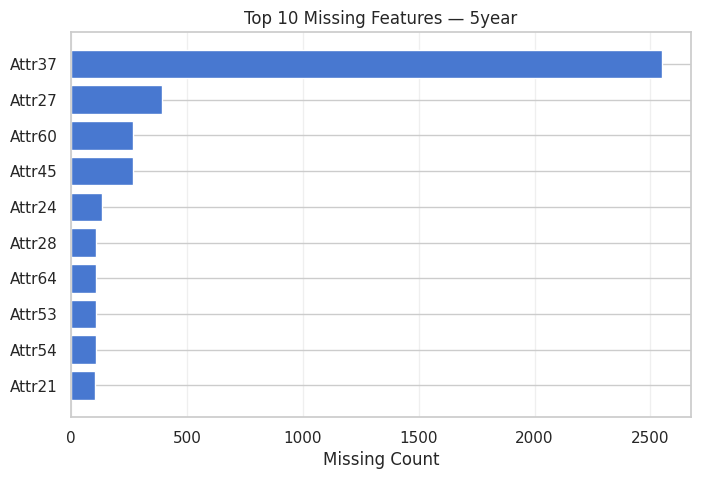

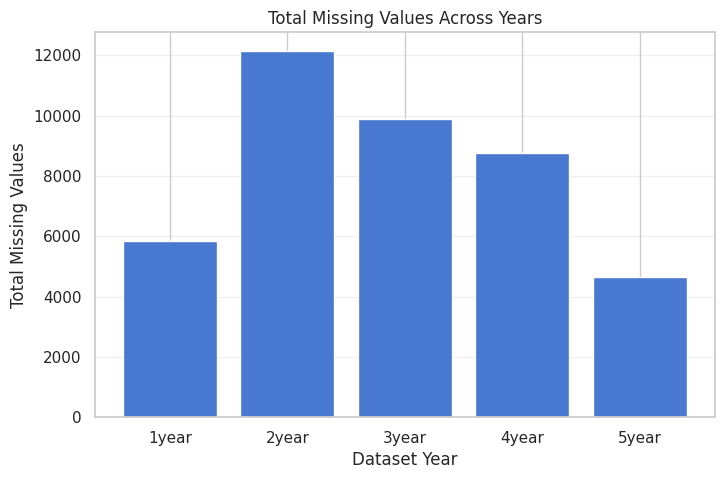

In [ ]:
#  missing values analysis
def missing_value_analysis_with_plots(bankruptcy_datasets, top_n=10, show_plots=True):
    """
    Analyzes missing values in each bankruptcy dataset results.

    This function:
     Computes total missing values
     Calculates percentage missing
     Prints top features with missing values (top_n)
     Optionally plots:
        1) Total missing values per year (bar chart)
        2) Top missing features per year (horizontal bar chart)

    Parameters:
    bankruptcy_datasets : dict
        Dictionary containing datasets for each year
        (keys: '1year' to '5year', values: pandas DataFrames)
    top_n : int
        Number of top missing features to show per year
    show_plots : bool
        If True, displays plots

    Returns:
    dict
        A dictionary containing:
         total_missing_per_year
         missing_percentage_per_year
         top_missing_features_per_year (top_n per year)
    """

    total_missing_per_year = {}
    missing_percentage_per_year = {}
    top_missing_features_per_year = {}

    for year, companies_df in bankruptcy_datasets.items():
        print(f"\n {year.upper()} MISSING VALUE ANALYSIS \n")

        # Total missing
        total_missing = int(companies_df.isna().sum().sum())
        total_cells = companies_df.shape[0] * companies_df.shape[1]
        missing_percentage = (total_missing / total_cells) * 100

        total_missing_per_year[year] = total_missing
        missing_percentage_per_year[year] = missing_percentage

        print(f"Total Missing Values: {total_missing}")
        print(f"Percentage Missing: {missing_percentage:.2f}%")

        # Missing per feature
        missing_per_feature = companies_df.isna().sum()
        missing_features = missing_per_feature[missing_per_feature > 0].sort_values(ascending=False)

        top_missing = missing_features.head(top_n)
        top_missing_features_per_year[year] = top_missing

        print("\nTop Features with Missing Values:")
        print(top_missing)

        #  Plot for top missing features for this year
        if show_plots and len(top_missing) > 0:
            plt.figure(figsize=(8, 5))
            plt.barh(top_missing.index[::-1], top_missing.values[::-1])
            plt.title(f"Top {top_n} Missing Features — {year}")
            plt.xlabel("Missing Count")
            plt.grid(axis="x", alpha=0.3)
            plt.show()

    #  Plot for total missing per year
    if show_plots:
        plt.figure(figsize=(8, 5))
        years = list(total_missing_per_year.keys())
        values = list(total_missing_per_year.values())

        plt.bar(years, values)
        plt.title("Total Missing Values Across Years")
        plt.xlabel("Dataset Year")
        plt.ylabel("Total Missing Values")
        plt.grid(axis="y", alpha=0.3)
        plt.show()

    return {
        "total_missing_per_year": total_missing_per_year,
        "missing_percentage_per_year": missing_percentage_per_year,
        "top_missing_features_per_year": top_missing_features_per_year
    }


#  FUNCTION CALL
missing_summary = missing_value_analysis_with_plots(bankruptcy_datasets, top_n=10, show_plots=True)


# Class Distribution & Imbalance Analysis (All Years)


 1YEAR CLASS DISTRIBUTION 

Class Counts:
class
0    6756
1     271
Name: count, dtype: int64

Class Percentages:
class
0    96.14
1     3.86
Name: count, dtype: float64


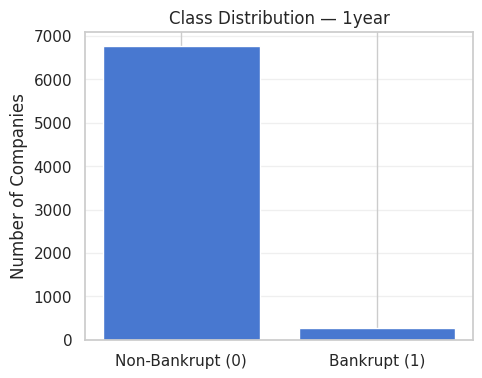


 2YEAR CLASS DISTRIBUTION 

Class Counts:
class
0    9773
1     400
Name: count, dtype: int64

Class Percentages:
class
0    96.07
1     3.93
Name: count, dtype: float64


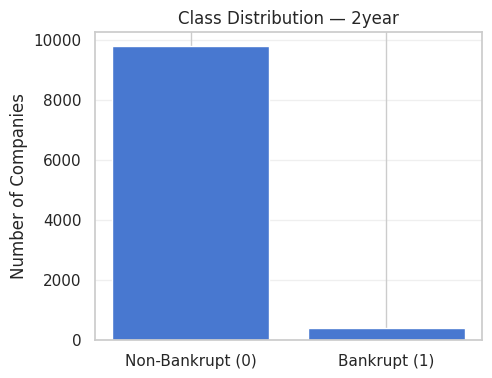


 3YEAR CLASS DISTRIBUTION 

Class Counts:
class
0    10008
1      495
Name: count, dtype: int64

Class Percentages:
class
0    95.29
1     4.71
Name: count, dtype: float64


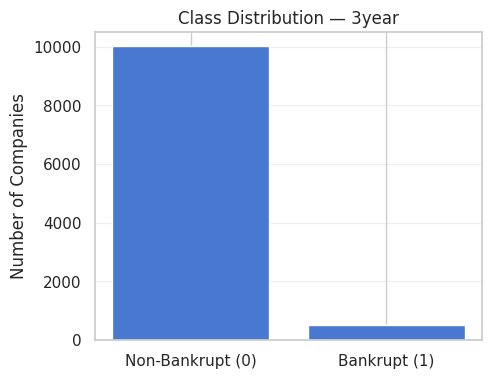


 4YEAR CLASS DISTRIBUTION 

Class Counts:
class
0    9277
1     515
Name: count, dtype: int64

Class Percentages:
class
0    94.74
1     5.26
Name: count, dtype: float64


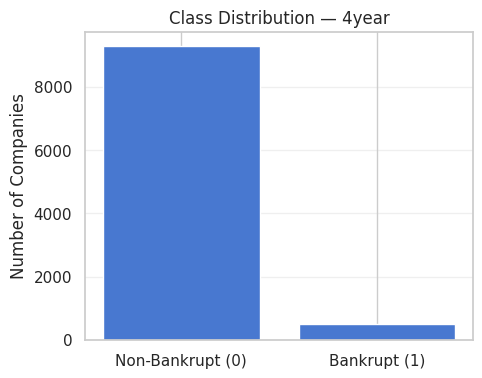


 5YEAR CLASS DISTRIBUTION 

Class Counts:
class
0    5500
1     410
Name: count, dtype: int64

Class Percentages:
class
0    93.06
1     6.94
Name: count, dtype: float64


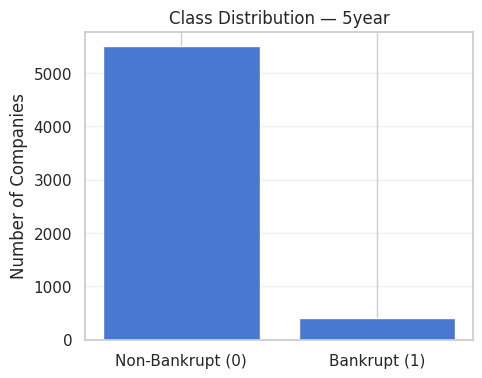

In [ ]:
# Analyzes class imbalance for all 5 years

def class_imbalance_analysis(bankruptcy_datasets, show_plots=True):
    """
    Analyzes class imbalance (bankrupt vs non-bankrupt)
    for each bankruptcy dataset.

    This function:
     Prints class counts and percentages
     Plots class distribution per year

    Parameters:
    bankruptcy_datasets : dict
        Dictionary of datasets (keys: '1year' to '5year',
        values: pandas DataFrames)
    show_plots : bool
        If True, displays bar plots

    Returns:
    dict
        Dictionary containing class distribution per year
    """

    class_distribution = {}

    for year, companies_df in bankruptcy_datasets.items():
        print(f"\n {year.upper()} CLASS DISTRIBUTION \n")

        counts = companies_df["class"].value_counts().sort_index()
        percentages = counts / counts.sum() * 100

        class_distribution[year] = {
            "counts": counts,
            "percentages": percentages
        }

        print("Class Counts:")
        print(counts)
        print("\nClass Percentages:")
        print(percentages.round(2))

        # Plot
        if show_plots:
            plt.figure(figsize=(5, 4))
            plt.bar(["Non-Bankrupt (0)", "Bankrupt (1)"], counts.values)
            plt.title(f"Class Distribution — {year}")
            plt.ylabel("Number of Companies")
            plt.grid(axis="y", alpha=0.3)
            plt.show()

    return class_distribution


# FUNCTION CALL
class_summary = class_imbalance_analysis(bankruptcy_datasets, show_plots=True)


In [ ]:
# correlation heatmap

def plot_correlation_heatmap(
    bankruptcy_datasets,
    year="1year",
    top_n=20
):
    """
    Plots a correlation heatmap for the selected bankruptcy dataset year.

    This function:
      Computes Pearson correlation between financial ratios
      Selects top_n most correlated features
      Displays a heatmap for easier interpretation

    Parameters:
    bankruptcy_datasets : dict
        Dictionary containing datasets for each year
        (keys: '1year' to '5year', values: pandas DataFrames)

    year : str, default="1year"
        Dataset year to analyze

    top_n : int, default=20
        Number of top correlated features to display

    Returns:
    None
        Displays a correlation heatmap
    """

    # Selecting dataset
    companies_df = bankruptcy_datasets[year]

    # Drop target column
    feature_df = companies_df.drop(columns=["class"])

    # Compute correlation matrix
    corr_matrix = feature_df.corr().abs()

    # Select top correlated features
    top_features = corr_matrix.mean().sort_values(ascending=False).head(top_n).index

    # Plot heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(
        corr_matrix.loc[top_features, top_features],
        cmap="coolwarm",
        linewidths=0.5,
        annot=False
    )

    plt.title(f"Top {top_n} Feature Correlations — {year} Dataset")
    plt.tight_layout()
    plt.show()


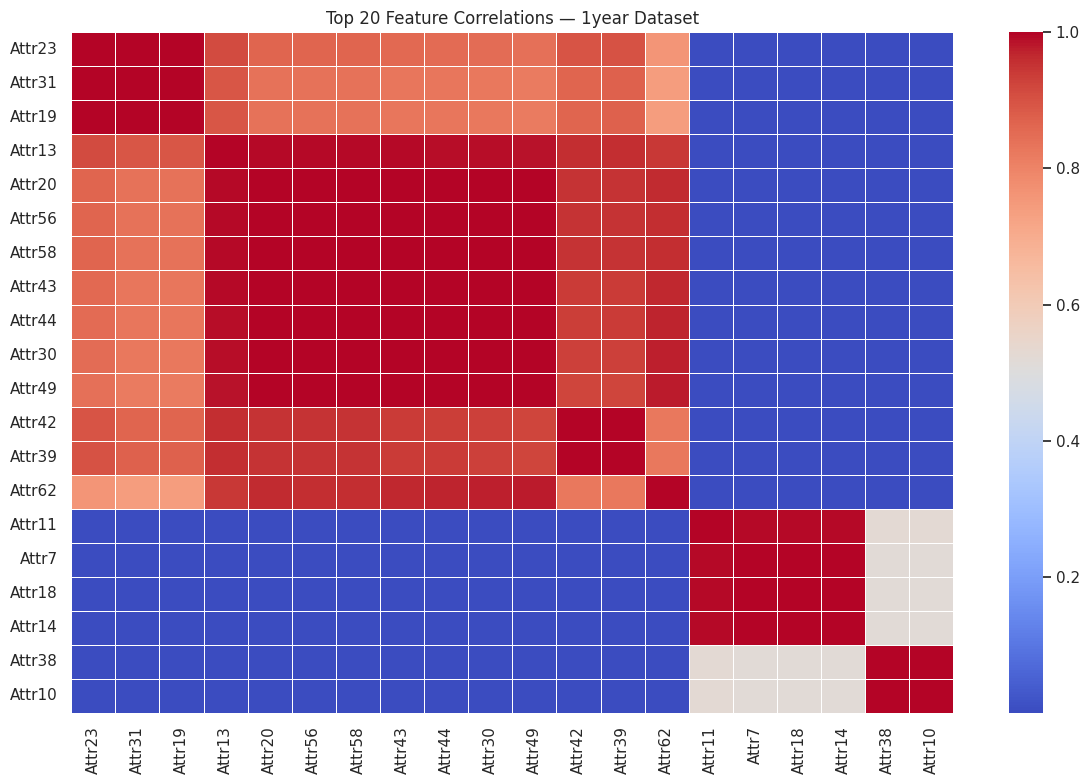

In [ ]:
#calling function

plot_correlation_heatmap(
    bankruptcy_datasets=bankruptcy_datasets,
    year="1year",
    top_n=20
)


# Data Pre-Processing


Applying median imputation — 1year
Missing values before imputation: 5835
Missing values after imputation:  0


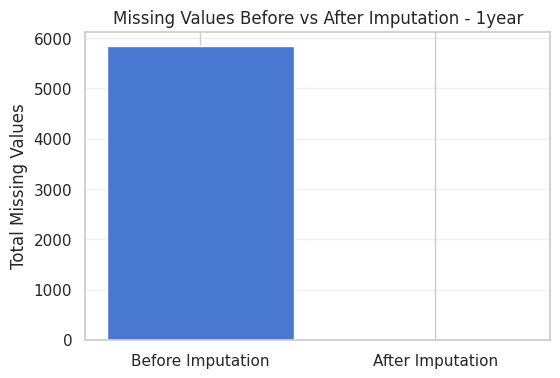


Applying median imputation — 2year
Missing values before imputation: 12157
Missing values after imputation:  0


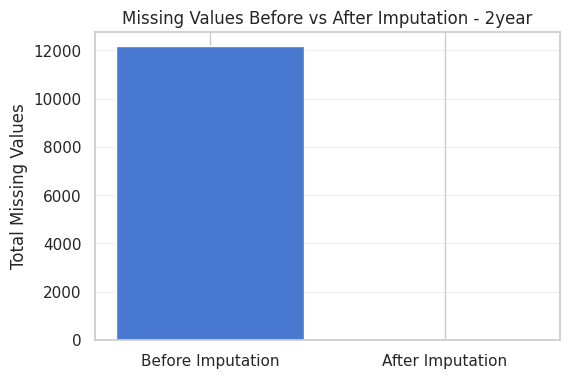


Applying median imputation — 3year
Missing values before imputation: 9888
Missing values after imputation:  0


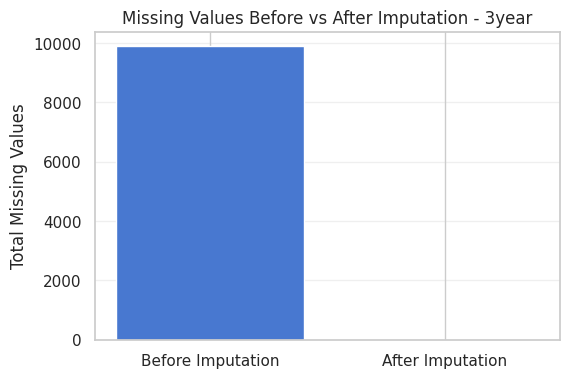


Applying median imputation — 4year
Missing values before imputation: 8776
Missing values after imputation:  0


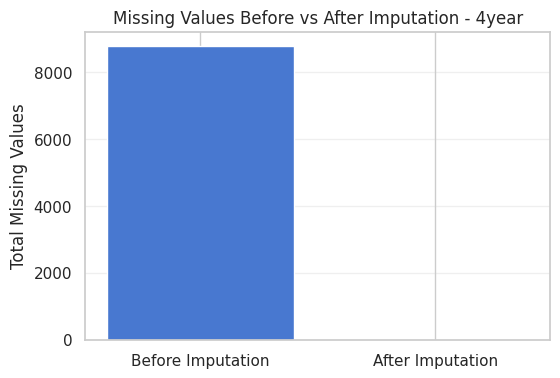


Applying median imputation — 5year
Missing values before imputation: 4666
Missing values after imputation:  0


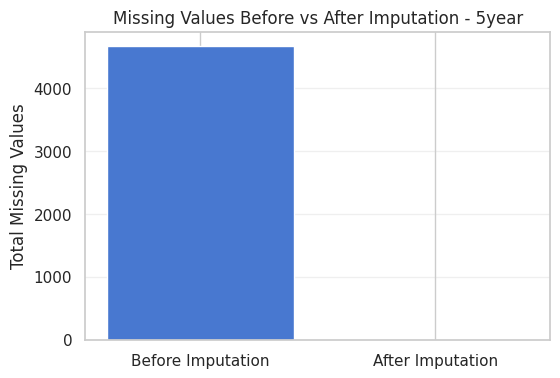

In [ ]:

# Median Imputation


def median_imputation(bankruptcy_datasets, show_plots=True):
    """
    Applies median imputation to handle missing values
    and visualizes missing values before and after imputation.

    Parameters:
    bankruptcy_datasets : dict
        Dictionary containing raw datasets for each year

    show_plots : bool
        Whether to display missing-value comparison plots

    Returns:
    dict
        Dictionary with imputed datasets
    """

    imputed_datasets = {}
    imputer = SimpleImputer(strategy="median")

    for year, companies_df in bankruptcy_datasets.items():
        print(f"\nApplying median imputation — {year}")

        # Missing values BEFORE
        missing_before = companies_df.isna().sum().sum()

        features = companies_df.drop("class", axis=1)
        target = companies_df["class"]

        # Apply imputation
        imputed_features = imputer.fit_transform(features)
        imputed_df = pd.DataFrame(imputed_features, columns=features.columns)
        imputed_df["class"] = target.values

        #  Missing values AFTER
        missing_after = imputed_df.isna().sum().sum()

        imputed_datasets[year] = imputed_df

        print(f"Missing values before imputation: {missing_before}")
        print(f"Missing values after imputation:  {missing_after}")

        # Missing values Before vs After Imputation
        if show_plots:
            plt.figure(figsize=(6, 4))
            plt.bar(
                ["Before Imputation", "After Imputation"],
                [missing_before, missing_after]
            )
            plt.title(f"Missing Values Before vs After Imputation - {year}")
            plt.ylabel("Total Missing Values")
            plt.grid(axis="y", alpha=0.3)
            plt.show()

    return imputed_datasets


# FUNCTION CALL
imputed_datasets = median_imputation(bankruptcy_datasets, show_plots=True)


# Outlier treatment with IQR method


Applying IQR outlier treatment — 1year
Outlier treatment completed using IQR clipping.


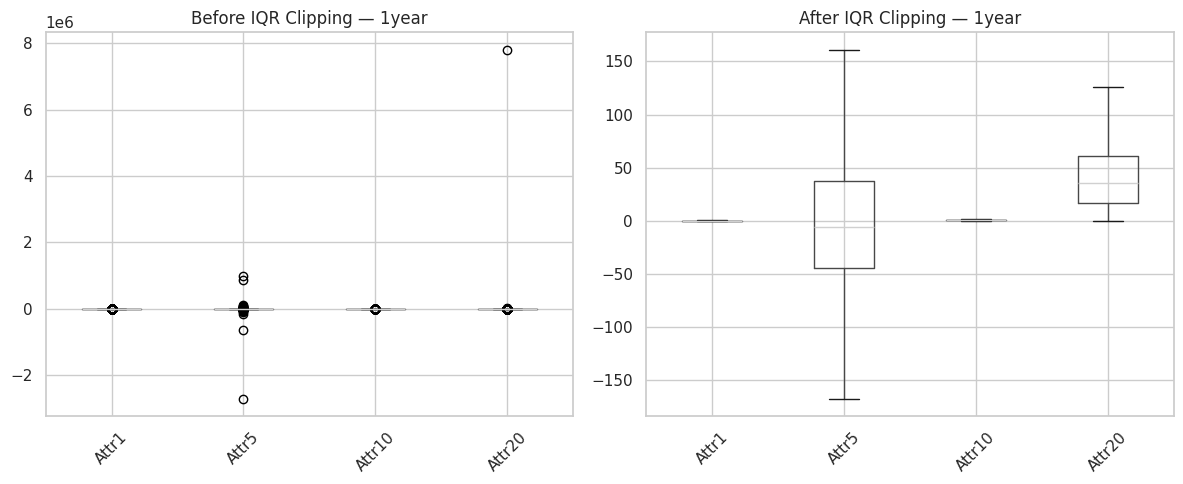


Applying IQR outlier treatment — 2year
Outlier treatment completed using IQR clipping.


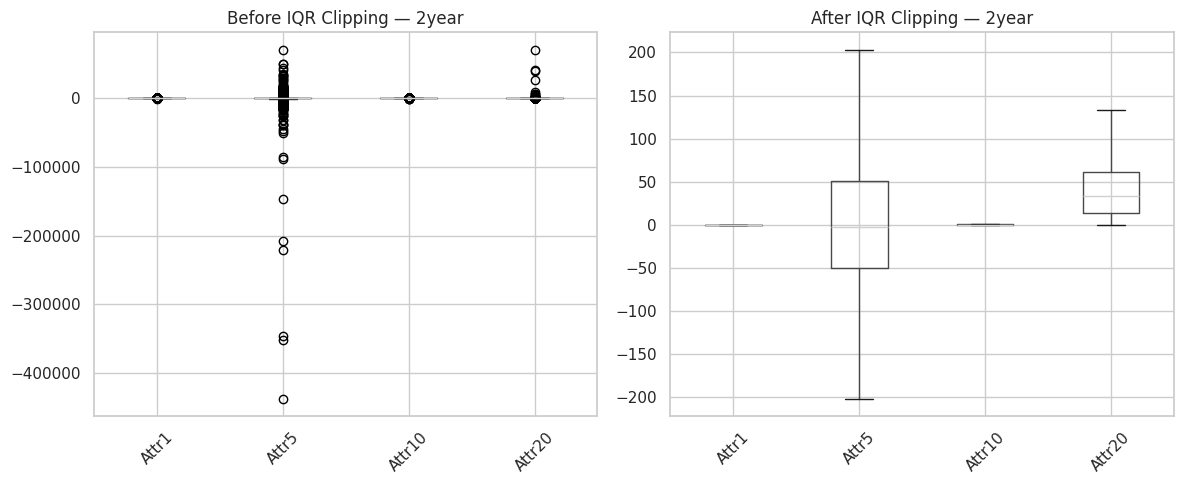


Applying IQR outlier treatment — 3year
Outlier treatment completed using IQR clipping.


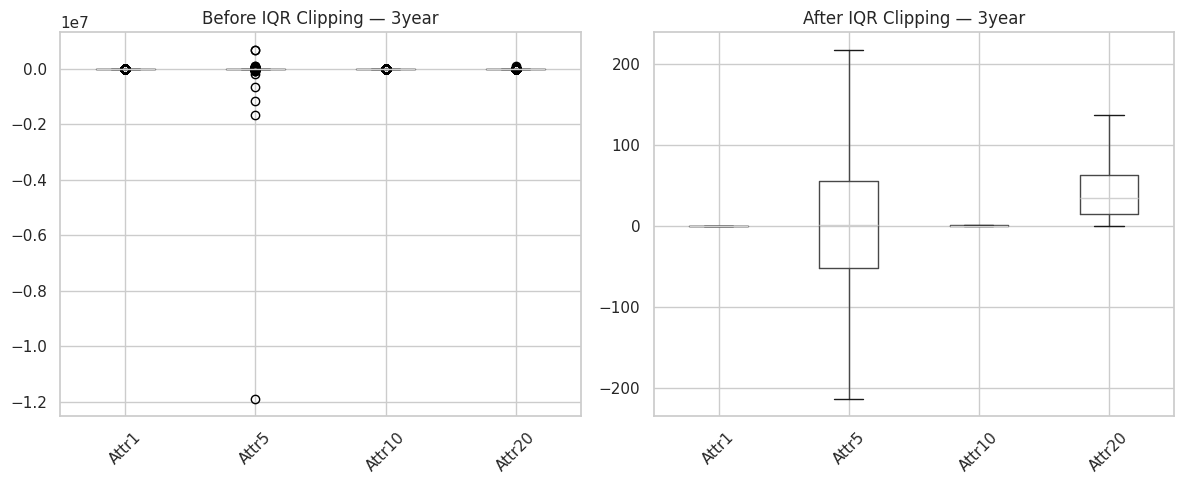


Applying IQR outlier treatment — 4year
Outlier treatment completed using IQR clipping.


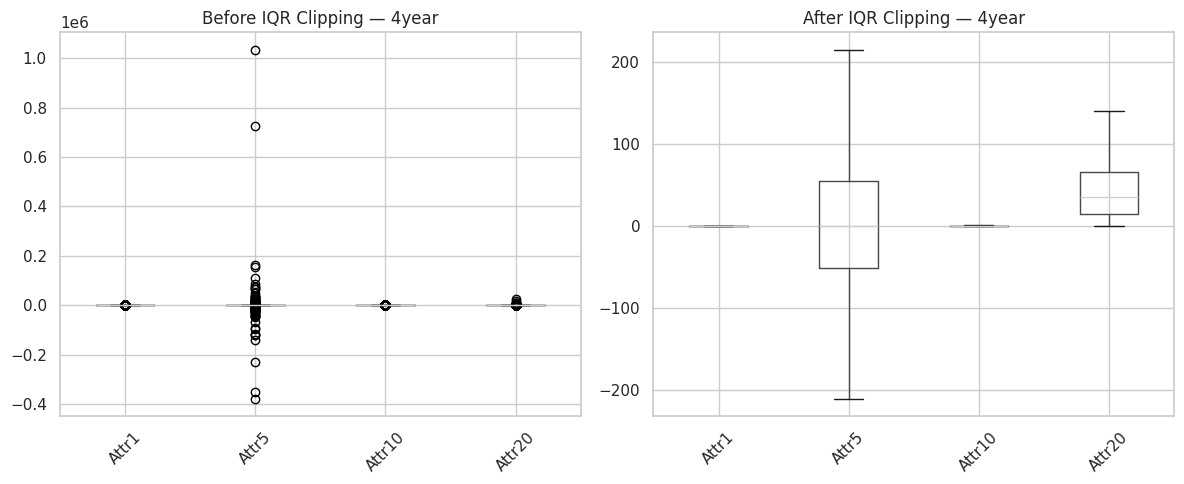


Applying IQR outlier treatment — 5year
Outlier treatment completed using IQR clipping.


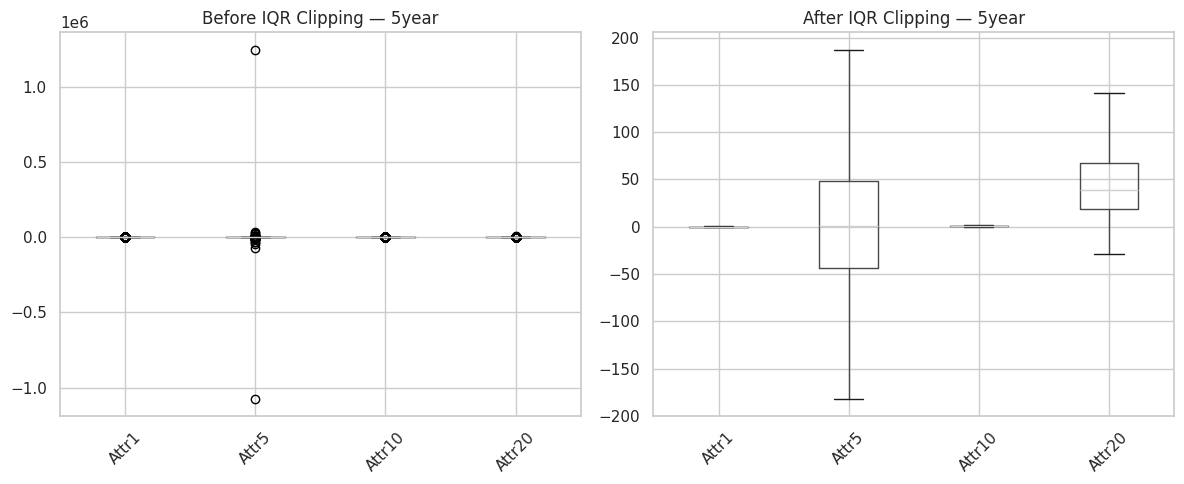

In [ ]:
# Outlier Treatment using IQR Clipping

def outlier_treatment(bankruptcy_datasets,
                                sample_features=None,
                                show_plots=True):
    """
    Applies IQR-based outlier clipping to financial features
    and visualizes distributions before and after treatment.

    Parameters:
    bankruptcy_datasets : dict
        Dictionary of imputed datasets (keys: '1year' to '5year')

    sample_features : list, optional
        List of feature names to visualize with boxplots.
        If None, a default set of features is used.

    show_plots : bool
        Whether to display before/after boxplots

    Returns:
    dict
        Dictionary with outlier-treated datasets
    """

    treated_datasets = {}

    # Default features for visualization
    if sample_features is None:
        sample_features = ["Attr1", "Attr5", "Attr10", "Attr20"]

    for year, companies_df in bankruptcy_datasets.items():
        print(f"\nApplying IQR outlier treatment — {year}")

        treated_df = companies_df.copy()

        feature_columns = treated_df.drop("class", axis=1).columns

        #  Applying IQR clipping
        for feature in feature_columns:
            Q1 = treated_df[feature].quantile(0.25)
            Q3 = treated_df[feature].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            treated_df[feature] = treated_df[feature].clip(lower_bound, upper_bound)

        treated_datasets[year] = treated_df

        print("Outlier treatment completed using IQR clipping.")

        # Visualization
        if show_plots:
            plt.figure(figsize=(12, 5))

            # Before
            plt.subplot(1, 2, 1)
            companies_df[sample_features].boxplot()
            plt.title(f"Before IQR Clipping — {year}")
            plt.xticks(rotation=45)

            # After
            plt.subplot(1, 2, 2)
            treated_df[sample_features].boxplot()
            plt.title(f"After IQR Clipping — {year}")
            plt.xticks(rotation=45)

            plt.tight_layout()
            plt.show()

    return treated_datasets


# FUNCTION CALL
outlier_treated_datasets = outlier_treatment(
    imputed_datasets,
    sample_features=["Attr1", "Attr5", "Attr10", "Attr20"],
    show_plots=True
)


# Feature Scaling (StandardScaler)

In [ ]:
# Feature Scaling using StandardScaler


def standard_scaling(bankruptcy_datasets, sample_features=None, show_plots=True):
    """
    Applies StandardScaler to normalize financial features
    and visualizes feature distributions before and after scaling.

    Parameters:
    bankruptcy_datasets : dict
        Dictionary of datasets after outlier treatment
        (keys: '1year' to '5year')

    sample_features : list, optional
        List of features to visualize distributions.
        If None, a default subset is used.

    show_plots : bool
        Whether to display before/after histograms

    Returns:
    dict
        Dictionary containing scaled datasets
    """

    scaled_datasets = {}

    if sample_features is None:
        sample_features = ["Attr1", "Attr5", "Attr10", "Attr20"]

    for year, companies_df in bankruptcy_datasets.items():
        print(f"\nApplying Standard Scaling — {year}")

        # Separate features and target
        X = companies_df.drop("class", axis=1)
        y = companies_df["class"]

        # Fit scaler per dataset
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # build DataFrame
        scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
        scaled_df["class"] = y.values

        scaled_datasets[year] = scaled_df
        print("Feature scaling completed.")

        #  Visualization
        if show_plots:
            fig, axes = plt.subplots(2, len(sample_features), figsize=(14, 6))

            for i, feature in enumerate(sample_features):
                # Before scaling
                axes[0, i].hist(X[feature], bins=30)
                axes[0, i].set_title(f"{feature} (Before)")

                # After scaling
                axes[1, i].hist(scaled_df[feature], bins=30)
                axes[1, i].set_title(f"{feature} (After)")

            fig.suptitle(f"Standard Scaling Effect — {year}", fontsize=14)
            plt.tight_layout()
            plt.show()

    return scaled_datasets



Applying Standard Scaling — 1year
Feature scaling completed.


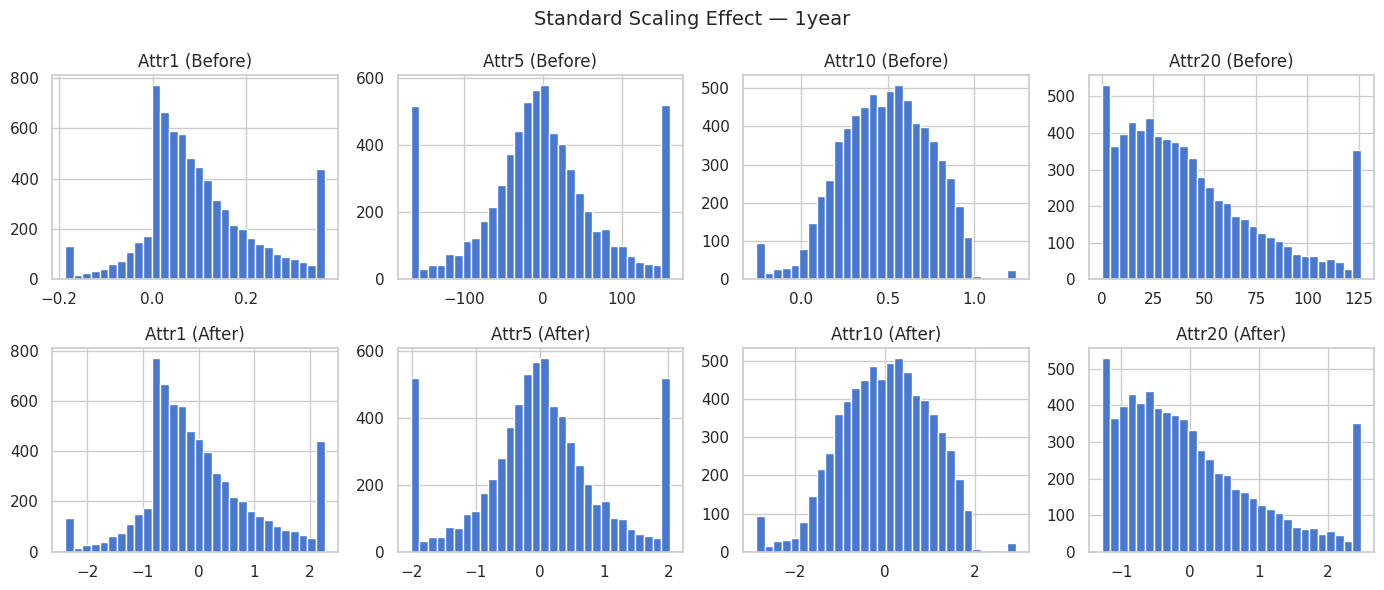


Applying Standard Scaling — 2year
Feature scaling completed.


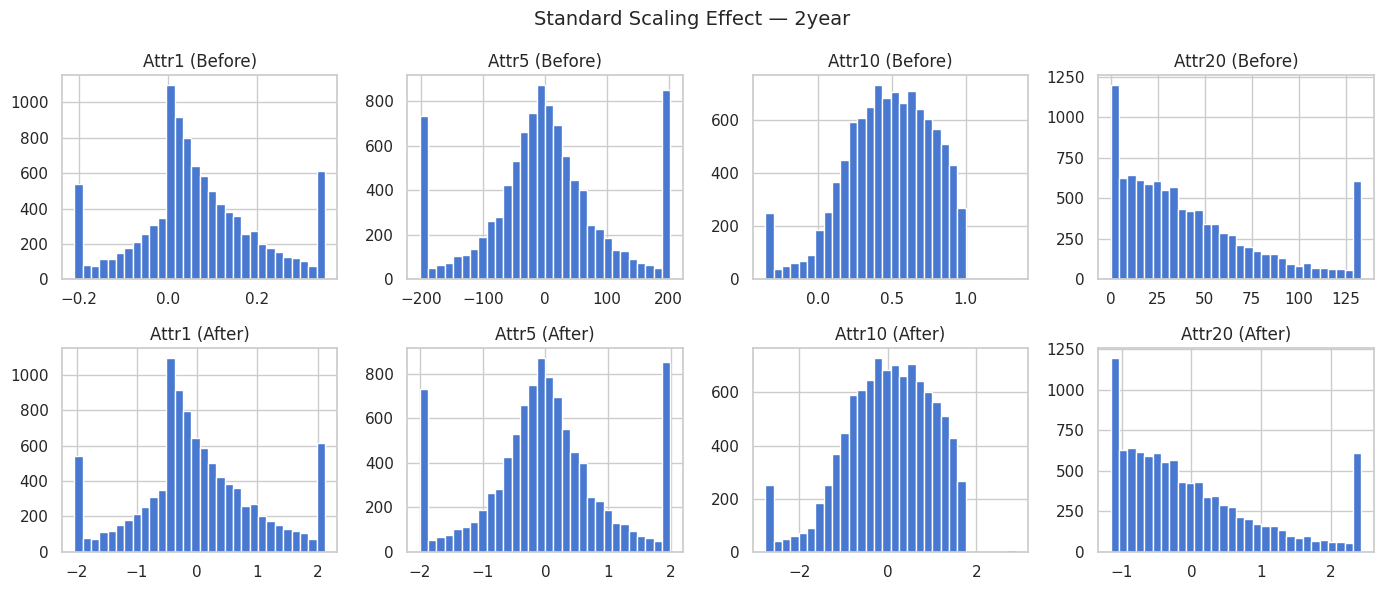


Applying Standard Scaling — 3year
Feature scaling completed.


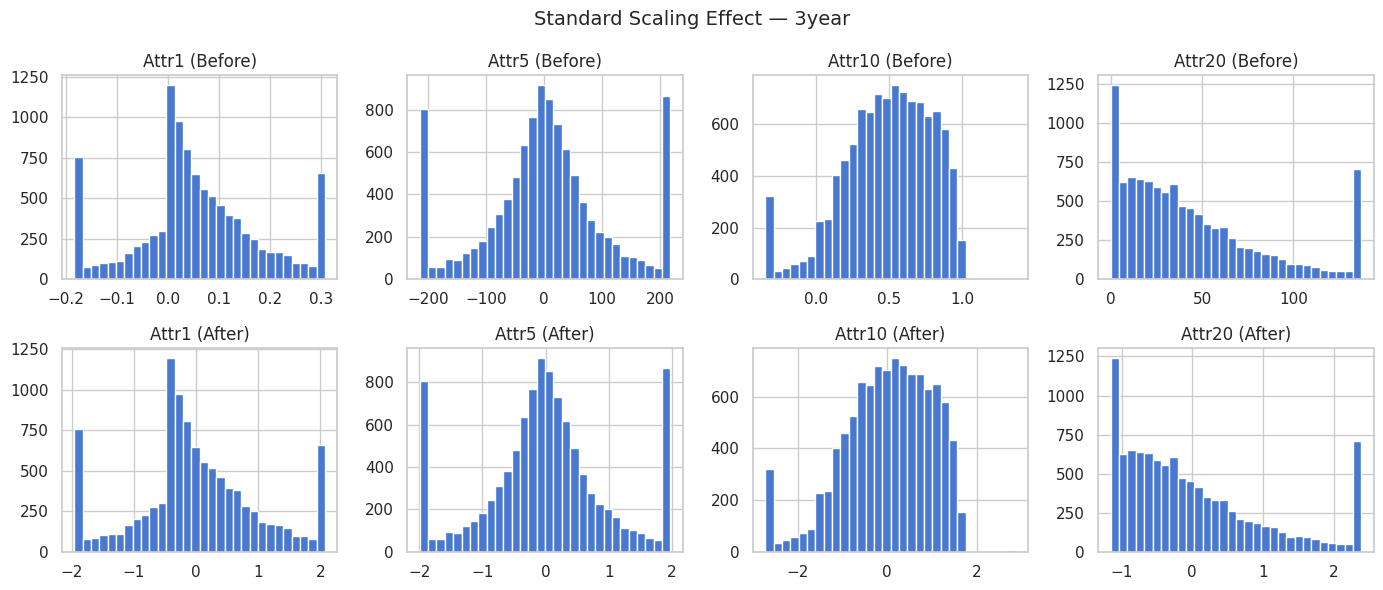


Applying Standard Scaling — 4year
Feature scaling completed.


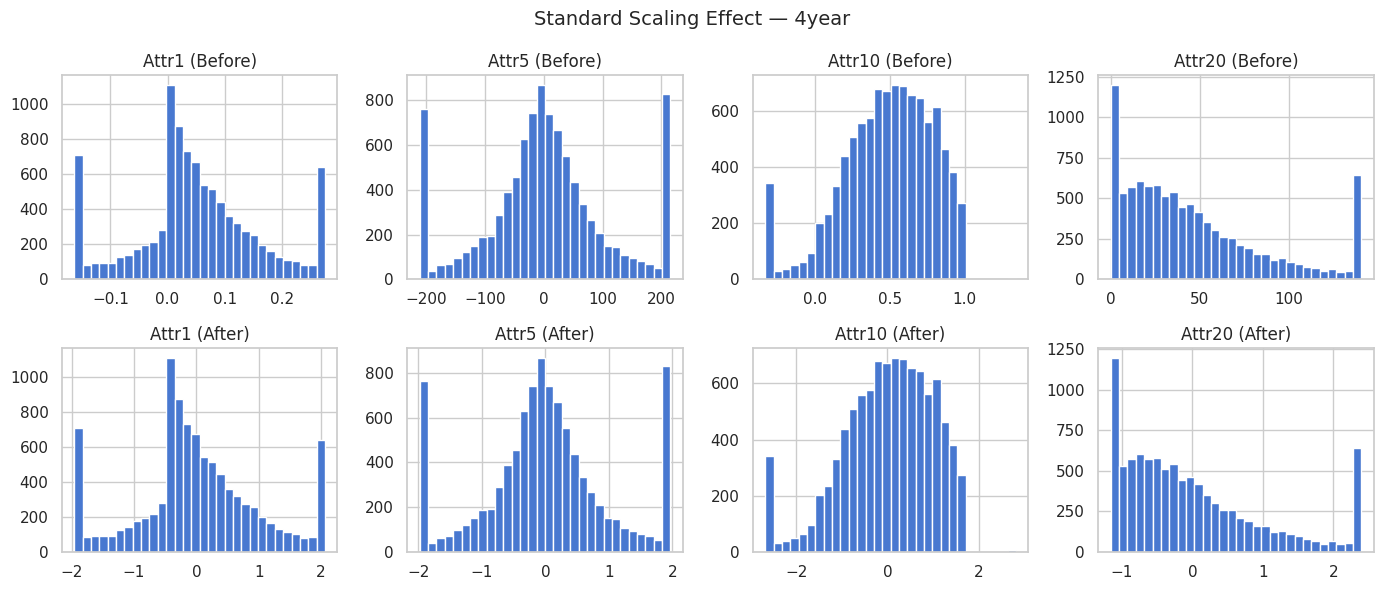


Applying Standard Scaling — 5year
Feature scaling completed.


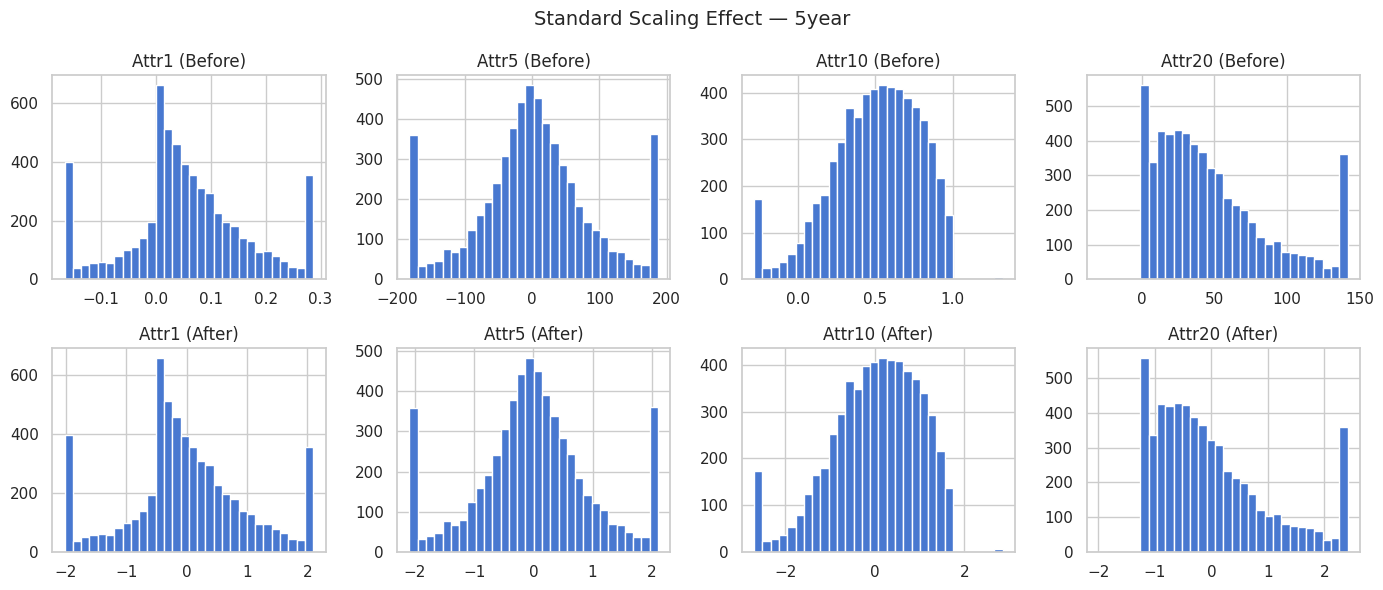

In [ ]:
#calling function

scaled_datasets = standard_scaling(
    outlier_treated_datasets,
    sample_features=["Attr1", "Attr5", "Attr10", "Attr20"],
    show_plots=True
)


# Class Imbalance Treatment using SMOTE

In [ ]:

# Class Imbalance Treatment using SMOTE


def apply_smote(bankruptcy_datasets, show_plots=True, random_state=42):
    """
    Applies SMOTE to balance bankrupt and non-bankrupt classes.

    This function:
     Separates features and target
     Applies SMOTE oversampling
     Visualizes class distribution before and after SMOTE

    Parameters:
    bankruptcy_datasets : dict
        Dictionary of scaled datasets
        (keys: '1year' to '5year')

    show_plots : bool
        Whether to display class distribution plots

    random_state : int
        Random seed for reproducibility

    Returns:
    dict
        Dictionary containing SMOTE-balanced datasets
    """

    smote_datasets = {}
    smote = SMOTE(random_state=random_state)

    for year, companies_df in bankruptcy_datasets.items():
        print(f"\nApplying SMOTE — {year}")

        X = companies_df.drop("class", axis=1)
        y = companies_df["class"]

        # Before SMOTE distribution
        before_counts = y.value_counts().sort_index()

        # Apply SMOTE
        X_resampled, y_resampled = smote.fit_resample(X, y)

        # Create balanced DataFrame
        balanced_df = pd.DataFrame(X_resampled, columns=X.columns)
        balanced_df["class"] = y_resampled

        smote_datasets[year] = balanced_df

        # After SMOTE distribution
        after_counts = y_resampled.value_counts().sort_index()

        print("Class distribution before SMOTE:")
        print(before_counts)
        print("Class distribution after SMOTE:")
        print(after_counts)

        #  Visualization
        if show_plots:
            fig, axes = plt.subplots(1, 2, figsize=(10, 4))

            axes[0].bar(["Non-Bankrupt", "Bankrupt"], before_counts.values)
            axes[0].set_title(f"Before SMOTE — {year}")
            axes[0].set_ylabel("Count")

            axes[1].bar(["Non-Bankrupt", "Bankrupt"], after_counts.values)
            axes[1].set_title(f"After SMOTE — {year}")

            fig.suptitle(f"SMOTE Class Balancing — {year}")
            plt.tight_layout()
            plt.show()

    return smote_datasets



Applying SMOTE — 1year
Class distribution before SMOTE:
class
0    6756
1     271
Name: count, dtype: int64
Class distribution after SMOTE:
class
0    6756
1    6756
Name: count, dtype: int64


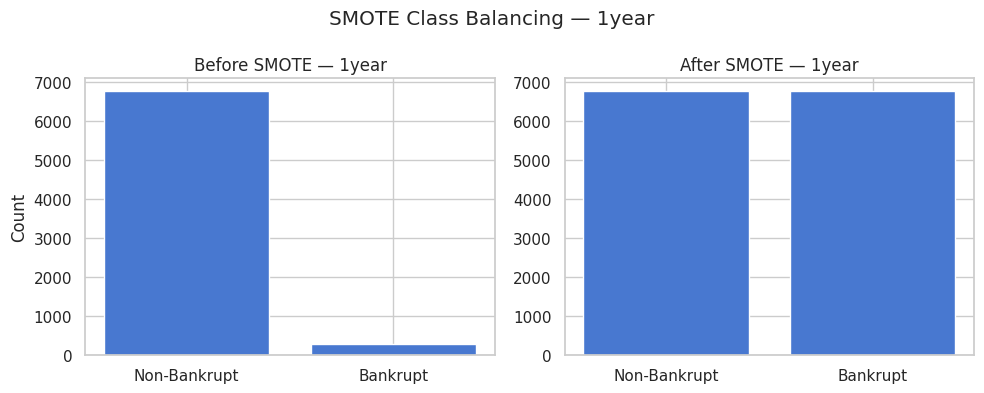


Applying SMOTE — 2year
Class distribution before SMOTE:
class
0    9773
1     400
Name: count, dtype: int64
Class distribution after SMOTE:
class
0    9773
1    9773
Name: count, dtype: int64


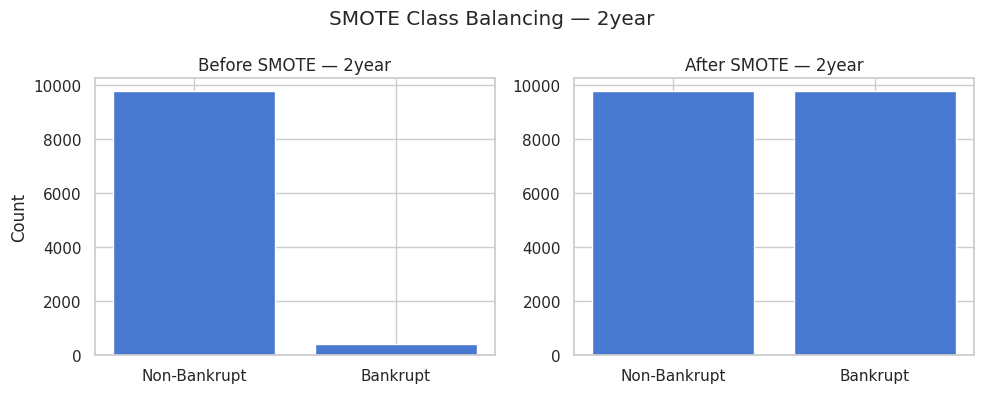


Applying SMOTE — 3year
Class distribution before SMOTE:
class
0    10008
1      495
Name: count, dtype: int64
Class distribution after SMOTE:
class
0    10008
1    10008
Name: count, dtype: int64


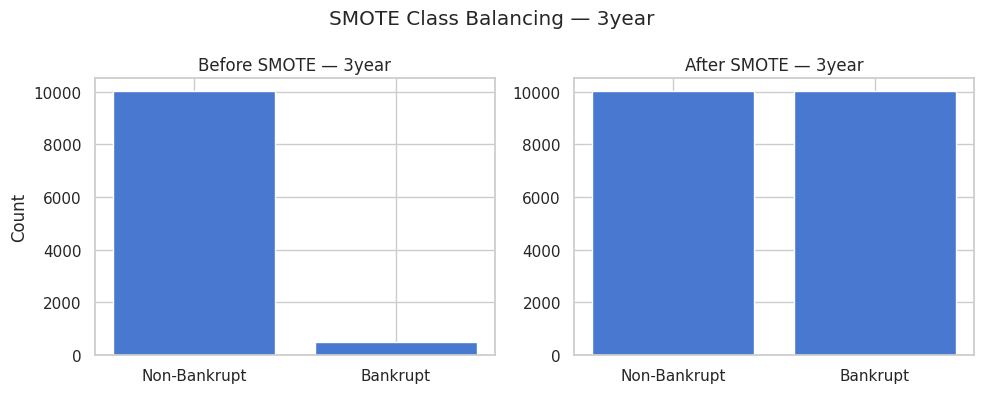


Applying SMOTE — 4year
Class distribution before SMOTE:
class
0    9277
1     515
Name: count, dtype: int64
Class distribution after SMOTE:
class
0    9277
1    9277
Name: count, dtype: int64


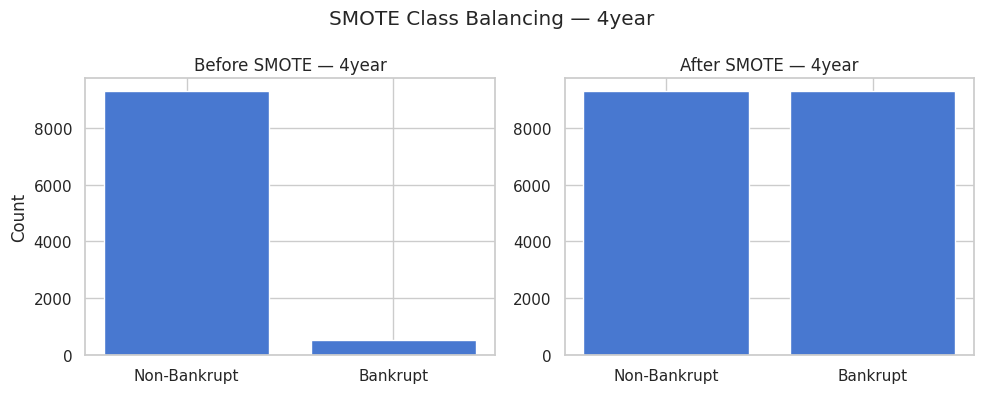


Applying SMOTE — 5year
Class distribution before SMOTE:
class
0    5500
1     410
Name: count, dtype: int64
Class distribution after SMOTE:
class
0    5500
1    5500
Name: count, dtype: int64


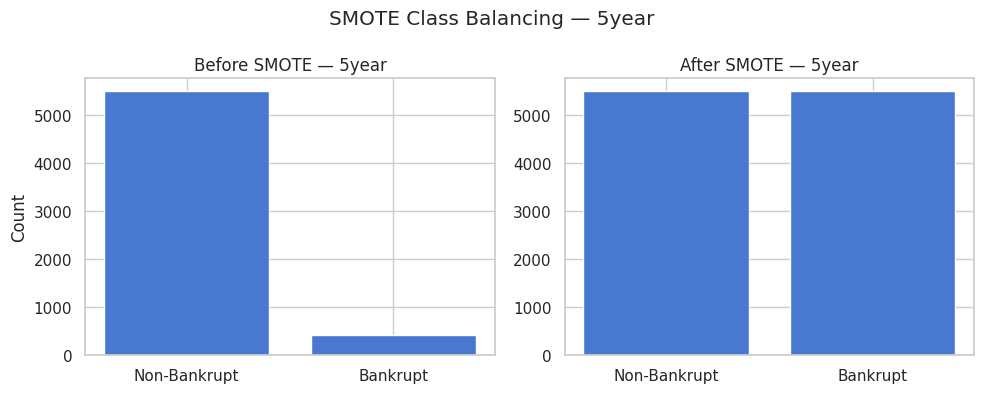

In [ ]:
#function calling

smote_datasets = apply_smote(
    scaled_datasets,
    show_plots=True,
    random_state=42
)


# Dimensionality Reduction using PCA

In [ ]:
# Dimensionality Reduction using PCA


def apply_pca(bankruptcy_datasets, variance_threshold=0.95, show_plots=True):
    """
    Applies PCA to reduce dimensionality while retaining a given
    percentage of explained variance.

    This function:
     Fits PCA on feature data
     Selects number of components based on variance threshold
     Plots cumulative explained variance

    Parameters:
    bankruptcy_datasets : dict
        Dictionary of SMOTE-balanced datasets
        (keys: '1year' to '5year')

    variance_threshold : float
        Percentage of variance to retain in PCA

    show_plots : bool
        Whether to display explained variance plots

    Returns:
    dict
        Dictionary containing PCA-transformed datasets
    """

    pca_datasets = {}

    for year, companies_df in bankruptcy_datasets.items():
        print(f"\nApplying PCA — {year}")

        X = companies_df.drop("class", axis=1)
        y = companies_df["class"]

        # Fit PCA - full first to inspect variance
        pca_full = PCA()
        pca_full.fit(X)

        cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

        # Number of components to retain desired variance
        n_components = np.argmax(cumulative_variance >= variance_threshold) + 1

        print(f"Number of components to retain {variance_threshold*100:.0f}% variance: {n_components}")

        # Applying PCA with optimal components
        pca = PCA(n_components=n_components)
        X_pca = pca.fit_transform(X)

        pca_df = pd.DataFrame(
            X_pca,
            columns=[f"PC{i+1}" for i in range(n_components)]
        )
        pca_df["class"] = y.values

        pca_datasets[year] = pca_df

        # Visualization
        if show_plots:
            plt.figure(figsize=(8, 5))
            plt.plot(cumulative_variance, marker="o")
            plt.axhline(y=variance_threshold, color="red", linestyle="--")
            plt.axvline(x=n_components-1, color="green", linestyle="--")
            plt.xlabel("Number of Components")
            plt.ylabel("Cumulative Explained Variance")
            plt.title(f"Cumulative Explained Variance — {year}")
            plt.grid(alpha=0.3)
            plt.show()

    return pca_datasets



Applying PCA — 1year
Number of components to retain 95% variance: 21


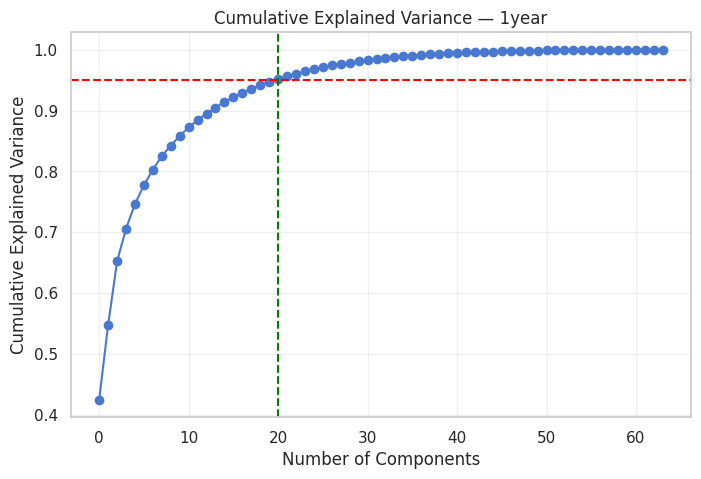


Applying PCA — 2year
Number of components to retain 95% variance: 23


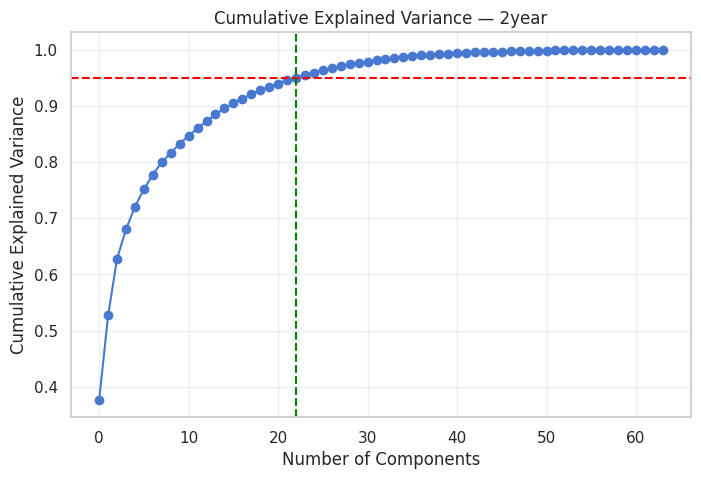


Applying PCA — 3year
Number of components to retain 95% variance: 23


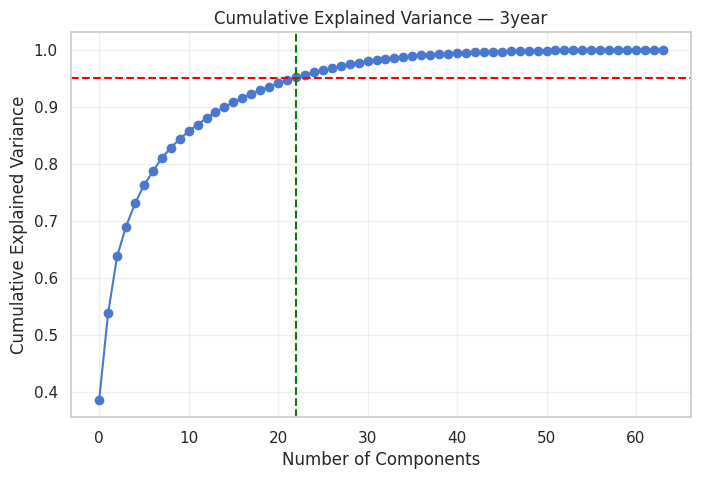


Applying PCA — 4year
Number of components to retain 95% variance: 23


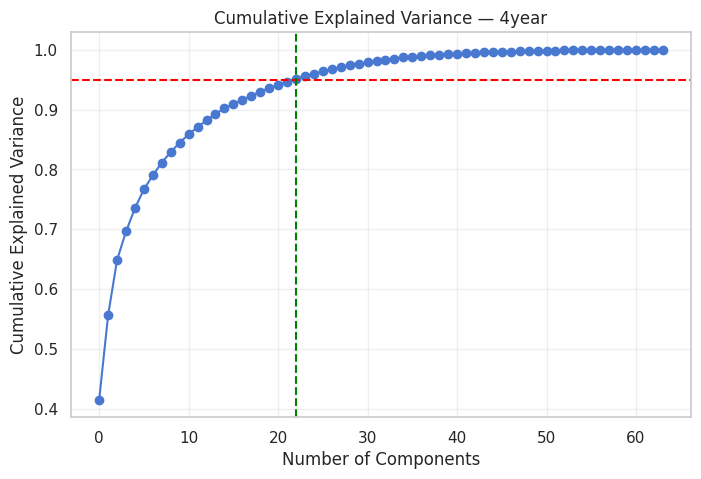


Applying PCA — 5year
Number of components to retain 95% variance: 22


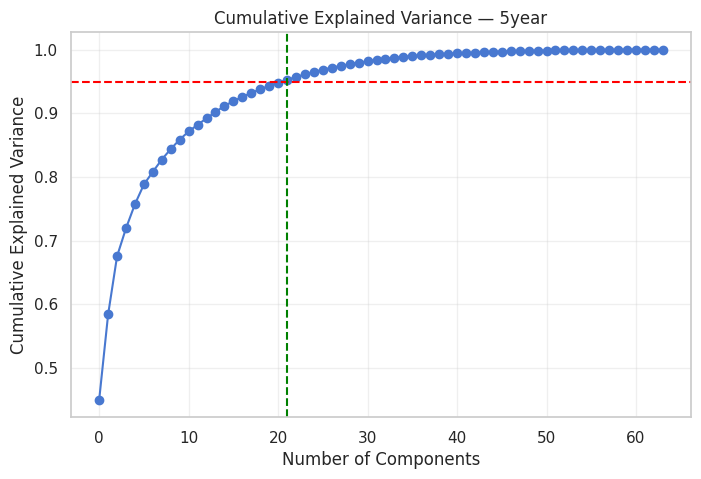

In [ ]:
#Function call

pca_datasets = apply_pca(
    smote_datasets,
    variance_threshold=0.95,
    show_plots=True
)


# Baseline  Model Building and Evaluation

In [ ]:

def train_baseline_models(pca_datasets, test_size=0.2, random_state=42):
    """
    Trains baseline gradient boosting models on PCA-transformed datasets.

    Models trained:
     XGBoost
     LightGBM
     CatBoost

    Evaluation metrics:
     Accuracy
     Precision
     Recall
     F1-score
     AUC

    Parameters:
    pca_datasets : dict
        Dictionary containing PCA-transformed datasets
        (keys: '1year' to '5year')
    test_size : float
        Proportion of test data
    random_state : int
        Random seed

    Returns:
    pd.DataFrame
        Model performance summary
    """

    results = []

    for year, companies_df in pca_datasets.items():
        print(f"\nTraining baseline models — {year}")

        X = companies_df.drop("class", axis=1)
        y = companies_df["class"]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=random_state
        )

        models = {
            "XGBoost": XGBClassifier(
                eval_metric="logloss",
                random_state=random_state,
                use_label_encoder=False
            ),
            "LightGBM": LGBMClassifier(random_state=random_state),
            "CatBoost": CatBoostClassifier(
                verbose=0,
                random_state=random_state
            )
        }

        for model_name, model in models.items():
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            y_prob = model.predict_proba(X_test)[:, 1]

            results.append({
                "Dataset": year,
                "Model": model_name,
                "Accuracy": accuracy_score(y_test, y_pred),
                "Precision": precision_score(y_test, y_pred, zero_division=0),
                "Recall": recall_score(y_test, y_pred),
                "F1-Score": f1_score(y_test, y_pred),
                "AUC": roc_auc_score(y_test, y_prob)
            })

    return pd.DataFrame(results)


In [ ]:
#function call

baseline_results = train_baseline_models(pca_datasets)
baseline_results



Training baseline models — 1year
[LightGBM] [Info] Number of positive: 5405, number of negative: 5404
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002067 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5355
[LightGBM] [Info] Number of data points in the train set: 10809, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500046 -> initscore=0.000185
[LightGBM] [Info] Start training from score 0.000185

Training baseline models — 2year
[LightGBM] [Info] Number of positive: 7818, number of negative: 7818
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003355 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 15636, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

Trai

,Dataset,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,1year,XGBoost,0.968553,0.948300,0.991118,0.969236,0.993868
1,1year,LightGBM,0.951905,0.922491,0.986677,0.953505,0.989777
2,1year,CatBoost,0.965964,0.943622,0.991118,0.966787,0.995657
3,2year,XGBoost,0.958056,0.931566,0.988747,0.959305,0.993010
4,2year,LightGBM,0.921739,0.887271,0.966240,0.925073,0.978239
5,2year,CatBoost,0.952174,0.923372,0.986189,0.953747,0.992006
6,3year,XGBoost,0.958541,0.934248,0.986513,0.959670,0.990499
7,3year,LightGBM,0.924076,0.893785,0.962537,0.926888,0.976610
8,3year,CatBoost,0.954046,0.926360,0.986513,0.955491,0.990347
9,4year,XGBoost,0.946106,0.916038,0.982210,0.947971,0.987431


In [ ]:
# AUC comparison of baseline models across forecasting horizons (1–5 years)

def plot_auc_comparison(baseline_results):
    """
    Plots AUC comparison of baseline models across forecasting horizons (1–5 years).

    Parameters:
    results_df : pandas.DataFrame
        DataFrame containing model evaluation results with columns:
        ['Dataset', 'Model', 'AUC']
    """

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=baseline_results,
        x="Dataset",
        y="AUC",
        hue="Model"
    )

    plt.title("Baseline Model AUC Comparison Across Forecasting Horizons")
    plt.xlabel("Years Before Bankruptcy")
    plt.ylabel("AUC Score")
    plt.ylim(0.9, 1.01)
    plt.legend(title="Model")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


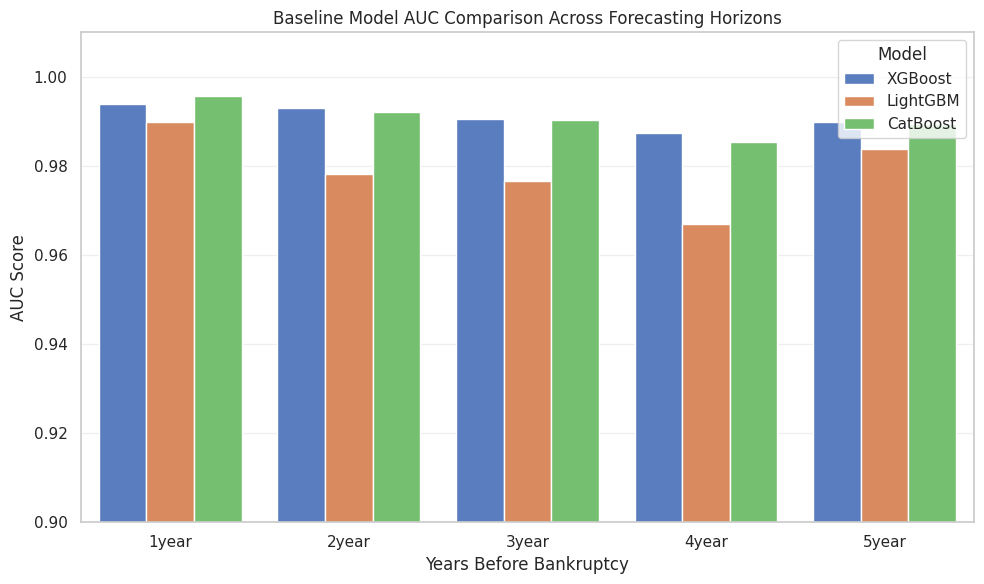

In [ ]:
#function call

plot_auc_comparison(baseline_results)


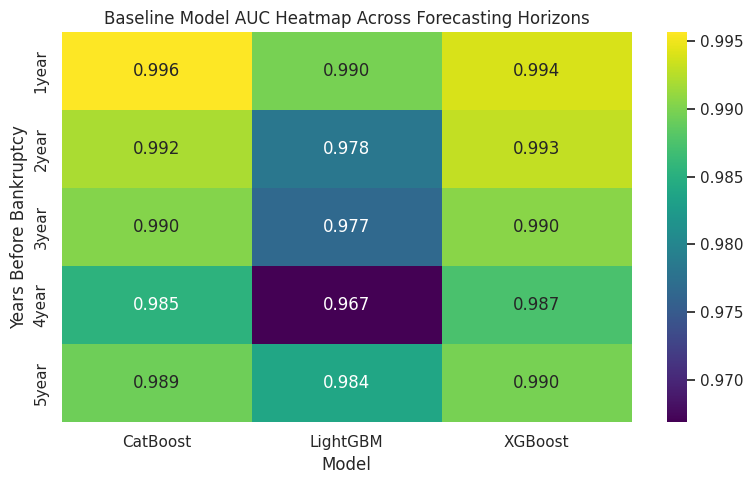

In [ ]:
def plot_auc_heatmap(baseline_results):
    """
    Plots a heatmap of AUC scores for baseline models
    across forecasting horizons (1–5 years).

    Parameters:
    baseline_results : pd.DataFrame
        DataFrame with columns ['Dataset', 'Model', 'AUC']

    Returns:
    None
    """

    heatmap_df = baseline_results.pivot(
        index="Dataset",
        columns="Model",
        values="AUC"
    )

    plt.figure(figsize=(8, 5))
    sns.heatmap(
        heatmap_df,
        annot=True,
        fmt=".3f",
        cmap="viridis"
    )
    plt.title("Baseline Model AUC Heatmap Across Forecasting Horizons")
    plt.xlabel("Model")
    plt.ylabel("Years Before Bankruptcy")
    plt.tight_layout()
    plt.show()


#calling function
plot_auc_heatmap(baseline_results)


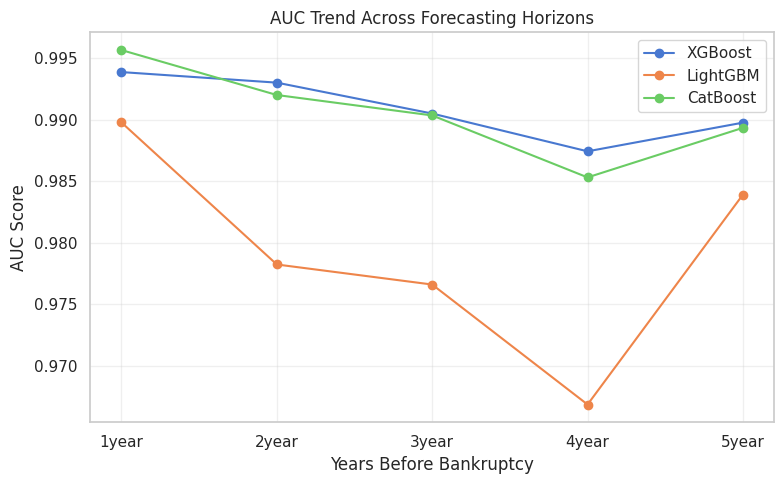

In [ ]:
def plot_auc_trend(baseline_results):
    """
    Plots AUC trend lines for baseline models
    across forecasting horizons.

    Parameters:
    baseline_results : pd.DataFrame

    Returns:
    None
    """

    plt.figure(figsize=(8, 5))

    for model in baseline_results["Model"].unique():
        subset = baseline_results[baseline_results["Model"] == model]
        plt.plot(
            subset["Dataset"],
            subset["AUC"],
            marker="o",
            label=model
        )

    plt.title("AUC Trend Across Forecasting Horizons")
    plt.xlabel("Years Before Bankruptcy")
    plt.ylabel("AUC Score")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_auc_trend(baseline_results)


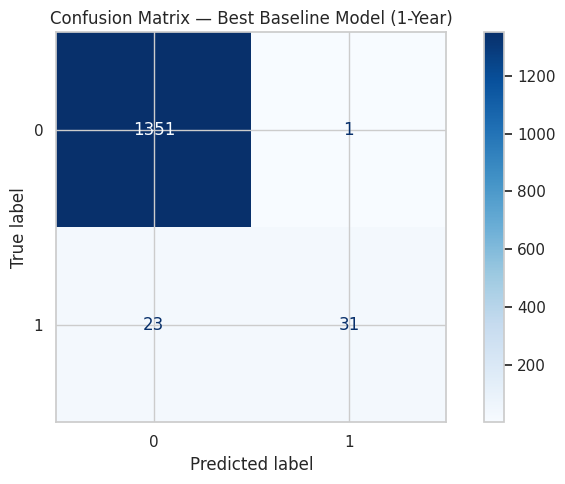

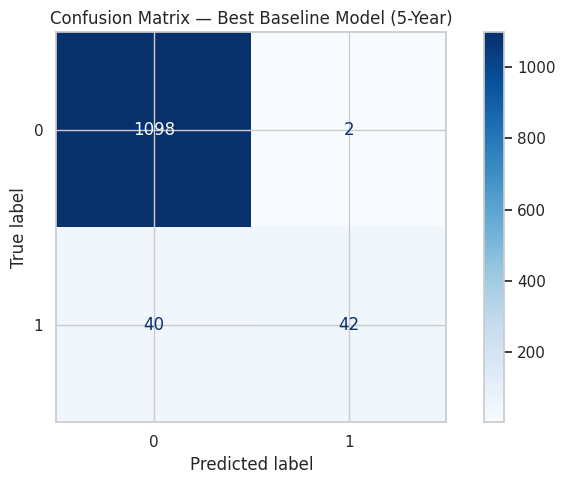

In [ ]:
#Trains the  model to  plots its confusion matrix.

def plot_confusion_matrix_best_model(
    dataset,
    model,
    title,
    random_state=42
):
    """
    Trains a model and plots its confusion matrix.

    Parameters:
    dataset : pd.DataFrame
        Dataset containing features and 'class' column

    model : classifier
        Binary classification model

    title : str
        Plot title

    random_state : int

    Returns:
    None
    """

    X = dataset.drop("class", axis=1)
    y = dataset["class"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=random_state
    )

    model.fit(X_train, y_train)

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        cmap="Blues"
    )

    plt.title(title)
    plt.tight_layout()
    plt.show()


# 1-Year Best Baseline
plot_confusion_matrix_best_model(
    dataset=scaled_datasets["1year"],
    model=CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.1,
        verbose=0,
        random_state=42
    ),
    title="Confusion Matrix — Best Baseline Model (1-Year)"
)

# 5-Year Best Baseline
plot_confusion_matrix_best_model(
    dataset=scaled_datasets["5year"],
    model=CatBoostClassifier(
        iterations=300,
        depth=10,
        learning_rate=0.1,
        l2_leaf_reg=3,
        verbose=0,
        random_state=42
    ),
    title="Confusion Matrix — Best Baseline Model (5-Year)"
)

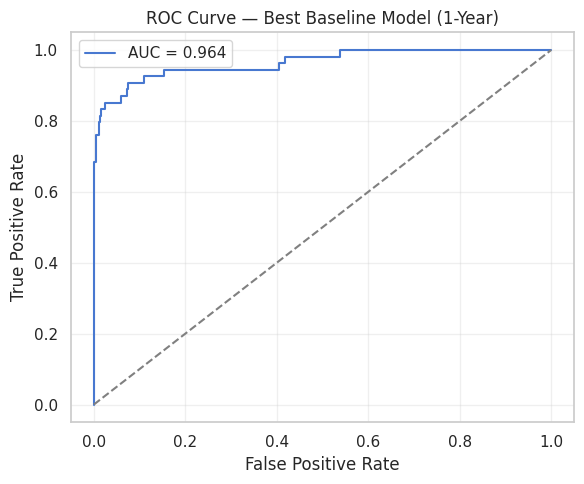

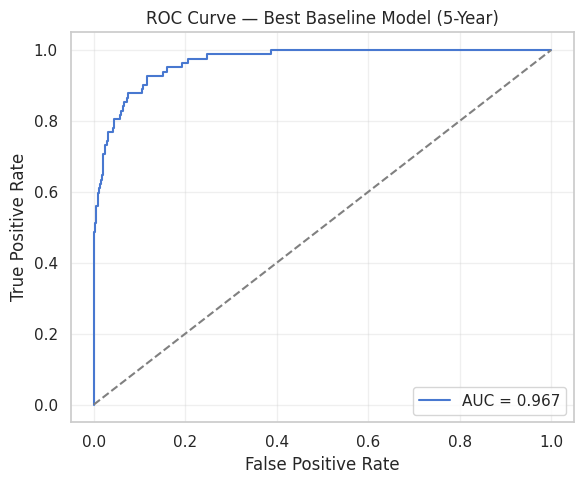

In [ ]:
# Roc metrics for best baseline model

def plot_roc_curve_best_model(
    dataset,
    model,
    dataset_name,
    random_state=42
):
    """
    Plots ROC curve for the best baseline model.

    Parameters:
    dataset : pd.DataFrame
    model : classifier
    dataset_name : str
    random_state : int

    Returns:
    None
    """

    X = dataset.drop("class", axis=1)
    y = dataset["class"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=random_state
    )

    model.fit(X_train, y_train)
    y_probs = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="grey")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — Best Baseline Model ({dataset_name})")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


#calling function

plot_roc_curve_best_model(
    scaled_datasets["1year"],
    CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.1,
        verbose=0,
        random_state=42
    ),
    "1-Year"
)

plot_roc_curve_best_model(
    scaled_datasets["5year"],
    CatBoostClassifier(
        iterations=300,
        depth=10,
        learning_rate=0.1,
        l2_leaf_reg=3,
        verbose=0,
        random_state=42
    ),
    "5-Year"
)

# Hyperparameter Tuning & Optimization

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

def tune_models(pca_datasets, random_state=42):
    """
    Performs hyperparameter tuning for XGBoost, LightGBM, and CatBoost
    using RandomizedSearchCV with AUC as the primary metric.

    Parameters:
    pca_datasets : dict
        PCA-transformed datasets for each year (1year–5year)

    random_state : int
        Random seed for reproducibility

    Returns:
    pd.DataFrame
        Optimized model performance summary
    """

    tuned_results = []

    param_grids = {
        "XGBoost": {
            "n_estimators": [50, 100],
            "max_depth": [3, 5],
            "learning_rate": [0.1],
            "subsample": [0.8],
            "colsample_bytree": [0.8]
        },
        "LightGBM": {
            "n_estimators": [50, 100],
            "num_leaves": [31, 40],
            "learning_rate": [0.1],
            "colsample_bytree": [0.8],
            "reg_alpha": [0],
            "reg_lambda": [1]
        },
        "CatBoost": {
            "iterations": [50, 100],
            "depth": [6, 8],
            "learning_rate": [0.1],
            "l2_leaf_reg": [3],
            "subsample": [0.8]
        }
    }

    model_objects = {
        "XGBoost": XGBClassifier(
            eval_metric="logloss",
            use_label_encoder=False,
            random_state=random_state
        ),
        "LightGBM": LGBMClassifier(random_state=random_state),
        "CatBoost": CatBoostClassifier(verbose=0, random_state=random_state)
    }

    for year, df in pca_datasets.items():
        print(f"\nHyperparameter tuning — {year}")

        X = df.drop("class", axis=1)
        y = df["class"]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=random_state
        )

        for model_name in model_objects:
            search = RandomizedSearchCV(
                model_objects[model_name],
                param_distributions=param_grids[model_name],
                scoring="roc_auc",
                n_iter=5,
                cv=2,
                random_state=random_state,
                n_jobs=-1
            )

            search.fit(X_train, y_train)
            best_model = search.best_estimator_

            y_pred = best_model.predict(X_test)
            y_prob = best_model.predict_proba(X_test)[:, 1]

            tuned_results.append({
                "Dataset": year,
                "Model": f"{model_name}_Tuned",
                "Accuracy": accuracy_score(y_test, y_pred),
                "Precision": precision_score(y_test, y_pred, zero_division=0),
                "Recall": recall_score(y_test, y_pred),
                "F1-Score": f1_score(y_test, y_pred),
                "AUC": roc_auc_score(y_test, y_prob)
            })

            print(f"{model_name} best AUC (CV): {search.best_score_:.4f}")

    return pd.DataFrame(tuned_results)


In [ ]:
#calling function

tuned_results = tune_models(pca_datasets)
tuned_results



Hyperparameter tuning — 1year
XGBoost best AUC (CV): 0.9636
[LightGBM] [Info] Number of positive: 5405, number of negative: 5404
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001918 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5355
[LightGBM] [Info] Number of data points in the train set: 10809, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500046 -> initscore=0.000185
[LightGBM] [Info] Start training from score 0.000185
LightGBM best AUC (CV): 0.9864
CatBoost best AUC (CV): 0.9870

Hyperparameter tuning — 2year
XGBoost best AUC (CV): 0.9482
[LightGBM] [Info] Number of positive: 7818, number of negative: 7818
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002919 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 156

,Dataset,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,1year,XGBoost_Tuned,0.924158,0.882510,0.978534,0.928045,0.971621
1,1year,LightGBM_Tuned,0.958565,0.931707,0.989637,0.959799,0.991446
2,1year,CatBoost_Tuned,0.955605,0.927134,0.988897,0.957020,0.993457
3,2year,XGBoost_Tuned,0.894885,0.858403,0.945780,0.899976,0.956309
4,2year,LightGBM_Tuned,0.936317,0.909702,0.968798,0.938321,0.983960
5,2year,CatBoost_Tuned,0.934527,0.902035,0.974936,0.937070,0.984353
6,3year,XGBoost_Tuned,0.888362,0.854861,0.935564,0.893394,0.957342
7,3year,LightGBM_Tuned,0.931069,0.903271,0.965534,0.933366,0.983324
8,3year,CatBoost_Tuned,0.925325,0.892216,0.967532,0.928349,0.979234
9,4year,XGBoost_Tuned,0.886284,0.850710,0.936927,0.891739,0.949660


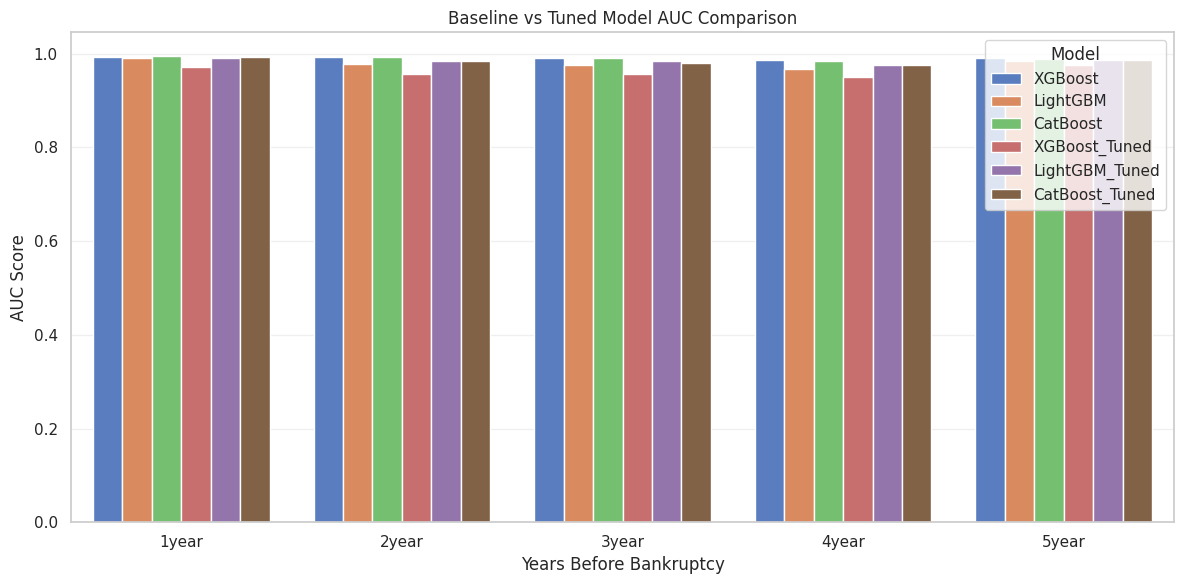

In [ ]:
def plot_baseline_vs_tuned(baseline_results, tuned_results):
    """
    Compares baseline and tuned model AUC across forecasting horizons.
    """

    combined = pd.concat([baseline_results, tuned_results])

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=combined,
        x="Dataset",
        y="AUC",
        hue="Model"
    )

    plt.title("Baseline vs Tuned Model AUC Comparison")
    plt.xlabel("Years Before Bankruptcy")
    plt.ylabel("AUC Score")
    plt.legend(title="Model")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_baseline_vs_tuned(baseline_results, tuned_results)


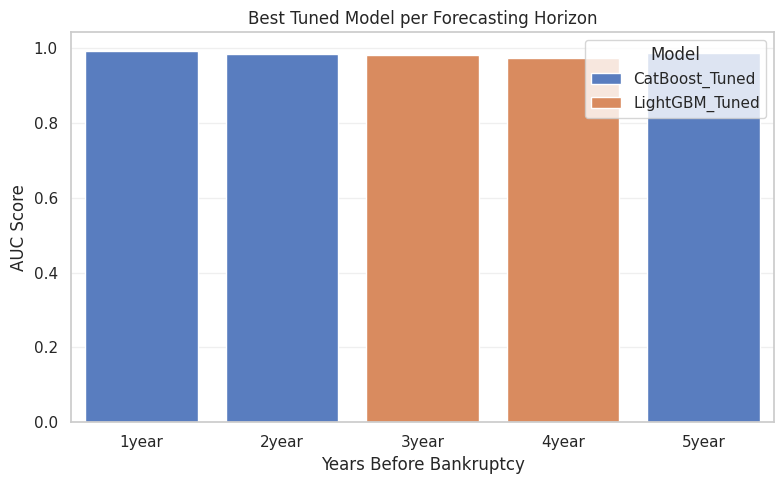

In [ ]:
def plot_best_tuned_model_per_year(tuned_results):
    """
    Displays the best tuned model per forecasting horizon based on AUC.
    """

    best_models = tuned_results.loc[
        tuned_results.groupby("Dataset")["AUC"].idxmax()
    ]

    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=best_models,
        x="Dataset",
        y="AUC",
        hue="Model"
    )

    plt.title("Best Tuned Model per Forecasting Horizon")
    plt.xlabel("Years Before Bankruptcy")
    plt.ylabel("AUC Score")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_best_tuned_model_per_year(tuned_results)


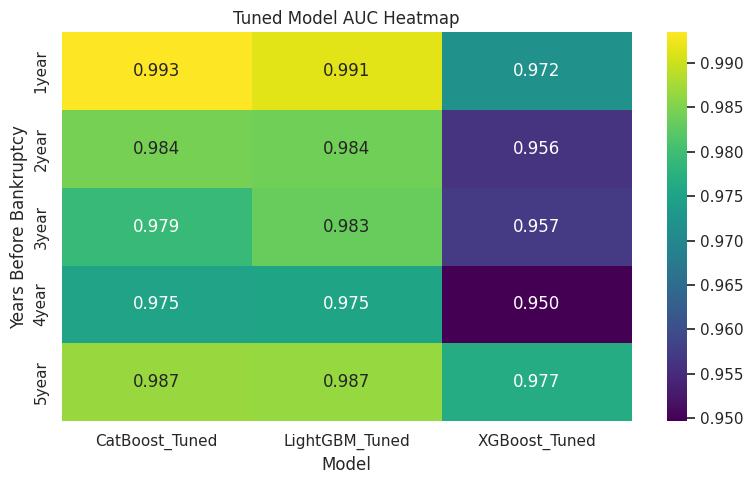

In [ ]:
def plot_tuned_auc_heatmap(tuned_results):
    """
    Heatmap of tuned model AUC across years.
    """

    heatmap_df = tuned_results.pivot(
        index="Dataset",
        columns="Model",
        values="AUC"
    )

    plt.figure(figsize=(8, 5))
    sns.heatmap(
        heatmap_df,
        annot=True,
        fmt=".3f",
        cmap="viridis"
    )

    plt.title("Tuned Model AUC Heatmap")
    plt.xlabel("Model")
    plt.ylabel("Years Before Bankruptcy")
    plt.tight_layout()
    plt.show()

plot_tuned_auc_heatmap(tuned_results)


In [ ]:
def plot_baseline_vs_tuned_auc(baseline_results, tuned_results):
    """
    Compares baseline and tuned model AUC scores across forecasting horizons.
    """

    baseline_df = baseline_results.copy()
    baseline_df["Type"] = "Baseline"

    tuned_df = tuned_results.copy()
    tuned_df["Type"] = "Tuned"

    combined = pd.concat([baseline_df, tuned_df])

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=combined,
        x="Dataset",
        y="AUC",
        hue="Type"
    )
    plt.title("Baseline vs Tuned Model AUC Comparison")
    plt.ylabel("AUC Score")
    plt.xlabel("Years Before Bankruptcy")
    plt.ylim(0.9, 1.01)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_tuned_auc_trend(tuned_results):
    """
    Plots AUC trends across forecasting horizons for tuned models.
    """

    plt.figure(figsize=(8, 5))

    for model in tuned_results["Model"].unique():
        subset = tuned_results[tuned_results["Model"] == model]
        plt.plot(subset["Dataset"], subset["AUC"], marker="o", label=model)

    plt.title("Tuned Model AUC Trend Across Forecasting Horizons")
    plt.xlabel("Years Before Bankruptcy")
    plt.ylabel("AUC Score")
    plt.ylim(0.9, 1.01)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:


def plot_confusion_matrix_best_model(
    scaled_datasets,
    year,
    model
):
    """
    Plots confusion matrix for the best tuned model.
    """

    df = scaled_datasets[year]
    X = df.drop("class", axis=1)
    y = df["class"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    model.fit(X_train, y_train)

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix — {year} Best Tuned Model")
    plt.show()


In [ ]:
#ROC curve for the best tuned model

def plot_roc_curve_best_model(
    scaled_datasets,
    year,
    model
):
    """
    Plots ROC curve for the best tuned model.
    """

    df = scaled_datasets[year]
    X = df.drop("class", axis=1)
    y = df["class"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {year} Best Tuned Model")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


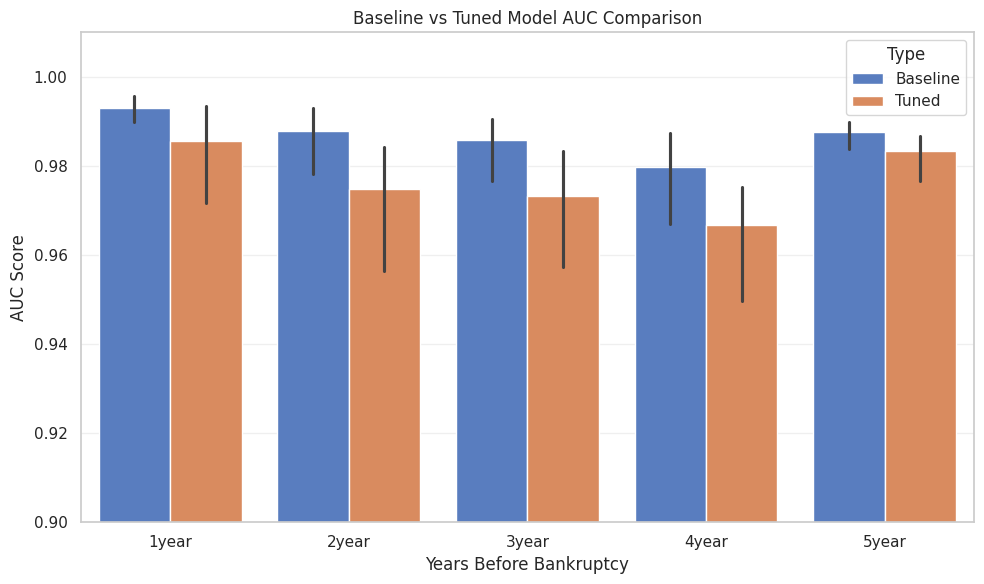

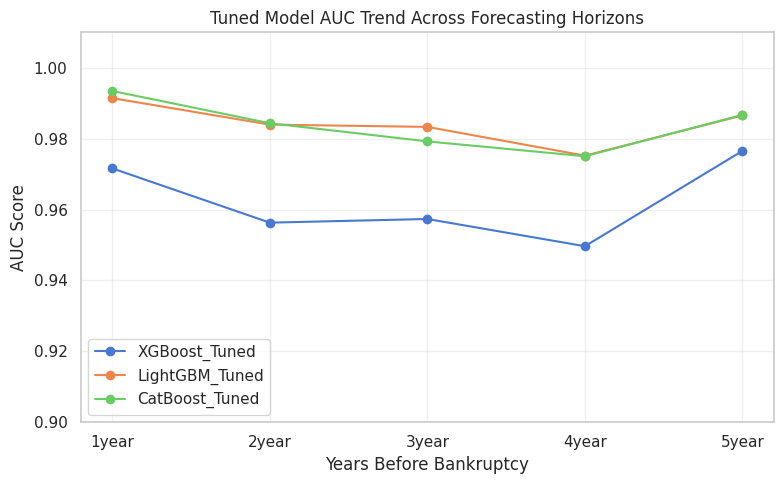

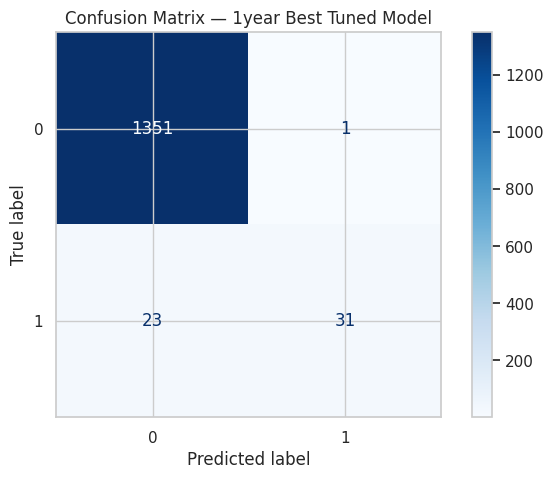

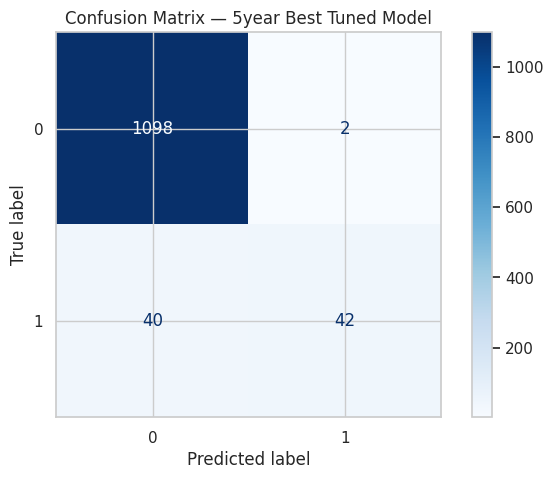

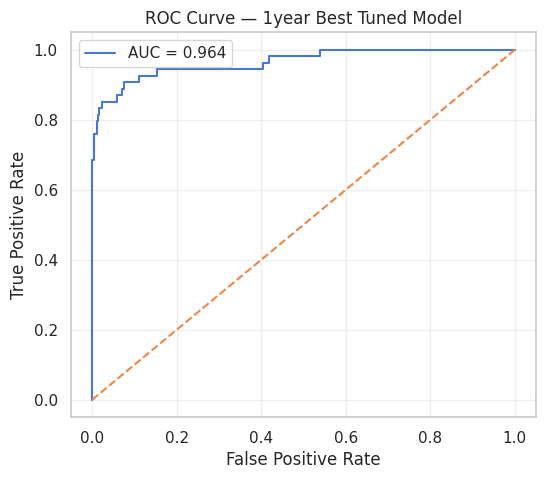

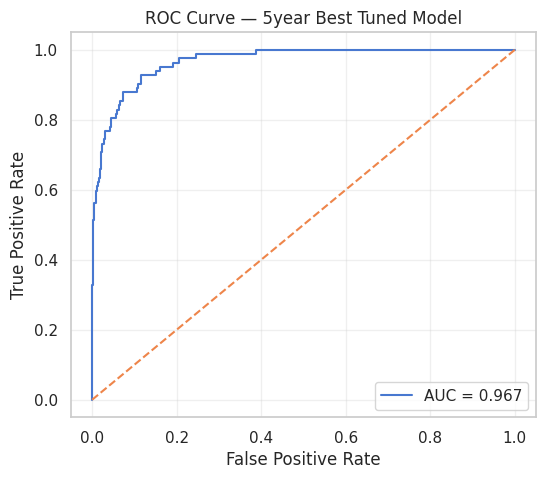

In [ ]:
# Baseline vs Tuned AUC
plot_baseline_vs_tuned_auc(baseline_results, tuned_results)

# Tuned AUC Trend
plot_tuned_auc_trend(tuned_results)

# Best tuned models
best_1year_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=42
)

best_5year_model = CatBoostClassifier(
    iterations=300,
    depth=10,
    learning_rate=0.1,
    l2_leaf_reg=3,
    verbose=0,
    random_state=42
)

# Confusion Matrices
plot_confusion_matrix_best_model(scaled_datasets, "1year", best_1year_model)
plot_confusion_matrix_best_model(scaled_datasets, "5year", best_5year_model)

# ROC Curves
plot_roc_curve_best_model(scaled_datasets, "1year", best_1year_model)
plot_roc_curve_best_model(scaled_datasets, "5year", best_5year_model)


In [ ]:
#SHAP for feature importance
def shap_feature_importance(
    model,
    X_train,
    X_test,
    sample_size=1000
):
    """
    Computes and visualizes SHAP feature importance
    for a trained tree-based model.

    Parameters:
    model : fitted model
        Best tuned CatBoost / LightGBM model
    X_train : pd.DataFrame
        Training feature set
    X_test : pd.DataFrame
        Test feature set
    sample_size : int
        Number of samples used for SHAP analysis

    Returns:
    None
        Displays SHAP summary plots
    """

    # Sample for speed
    X_sample = X_test.sample(
        min(sample_size, len(X_test)),
        random_state=42
    )

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)

    # Global importance
    shap.summary_plot(
        shap_values,
        X_sample,
        plot_type="bar",
        show=True
    )

    # Detailed impact
    shap.summary_plot(
        shap_values,
        X_sample,
        show=True
    )


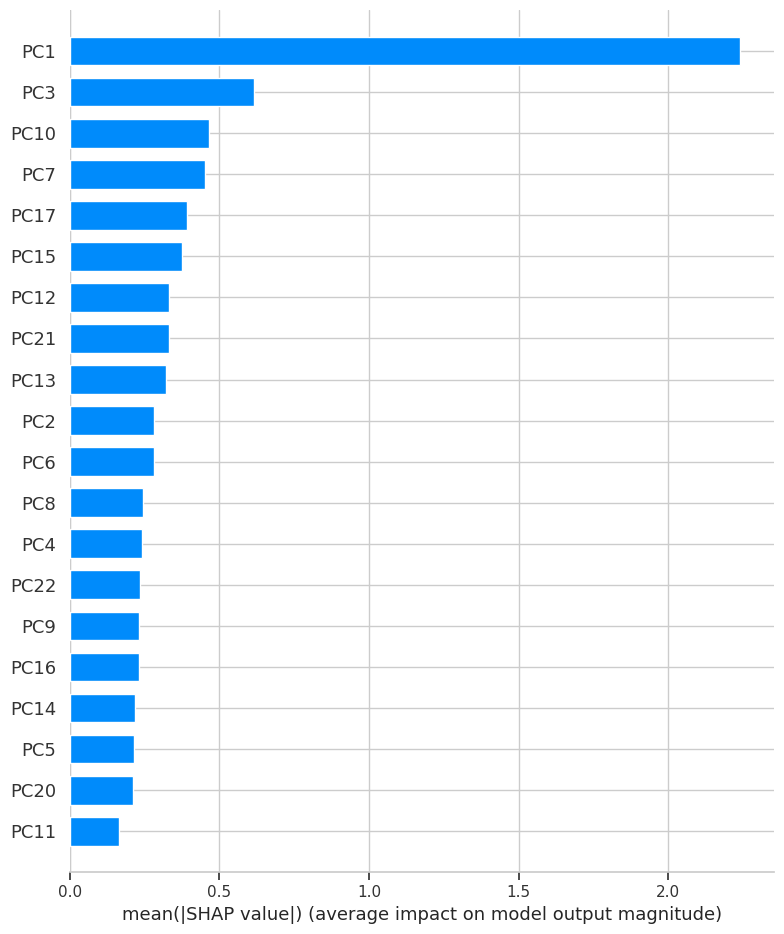

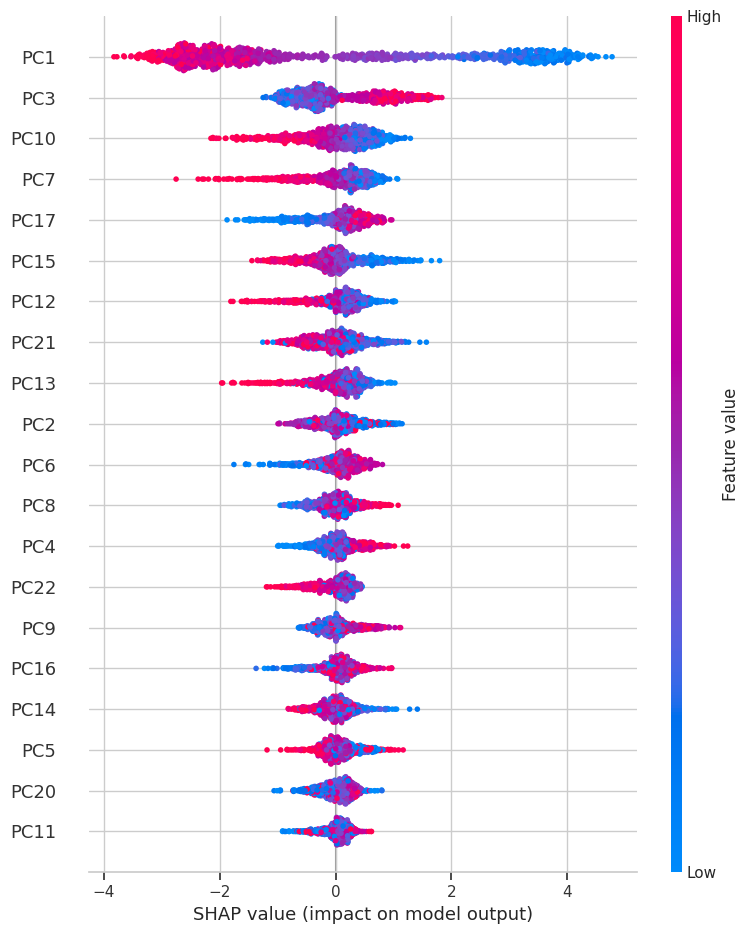

In [ ]:
#FUNCTION CALL (5-Year Best Tuned Model)
# Prepare data (5-Year)
df_5year = pca_datasets["5year"]
X = df_5year.drop("class", axis=1)
y = df_5year["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

best_5year_model = CatBoostClassifier(
    iterations=300,
    depth=10,
    learning_rate=0.1,
    l2_leaf_reg=3,
    verbose=0,
    random_state=42
)

best_5year_model.fit(X_train, y_train)

# SHAP analysis
shap_feature_importance(
    best_5year_model,
    X_train,
    X_test
)


In [ ]:
#SHAP Beeswarm Plot

def plot_shap_beeswarm(
    model,
    X_test,
    sample_size=1000
):
    """
    Generates a SHAP beeswarm plot to show
    direction and magnitude of feature impact
    on bankruptcy prediction.

    Parameters:
    model : fitted model
        Trained tree-based model (CatBoost / LightGBM)
    X_test : pd.DataFrame
        Test feature set
    sample_size : int, optional
        Number of samples used for SHAP (controls speed)

    Returns:
    None
        Displays SHAP beeswarm plot
    """

    # Sample data for speed
    X_sample = X_test.sample(
        min(sample_size, len(X_test)),
        random_state=42
    )

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)

    shap.summary_plot(
        shap_values,
        X_sample,
        plot_type="dot",
        show=True
    )


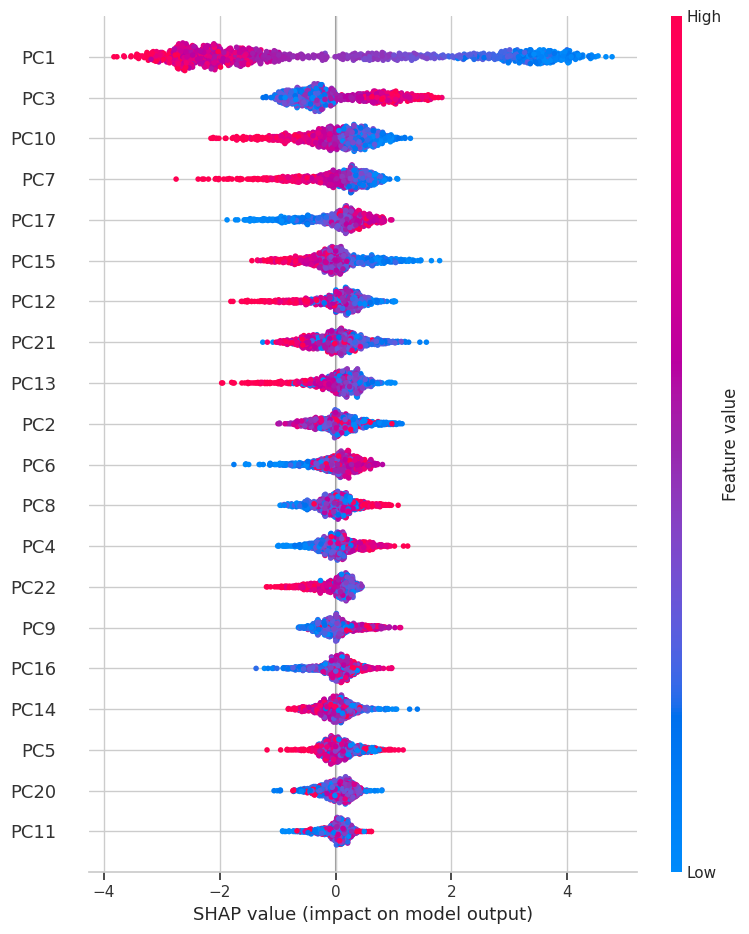

In [ ]:
#calling function
plot_shap_beeswarm(
    model=best_5year_model,
    X_test=X_test,
    sample_size=1000
)


In [ ]:
#SHAP Waterfall Plot

def plot_shap_waterfall(
    model,
    X_test,
    sample_index=0
):
    """
    Generates a SHAP waterfall plot explaining
    a single bankruptcy prediction.

    Parameters:
    model : fitted model
        Trained tree-based model
    X_test : pd.DataFrame
        Test feature set
    sample_index : int
        Index of the instance to explain

    Returns:
    None
        Displays SHAP waterfall plot
    """

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[sample_index],
            base_values=explainer.expected_value,
            data=X_test.iloc[sample_index],
            feature_names=X_test.columns
        ),
        show=True
    )


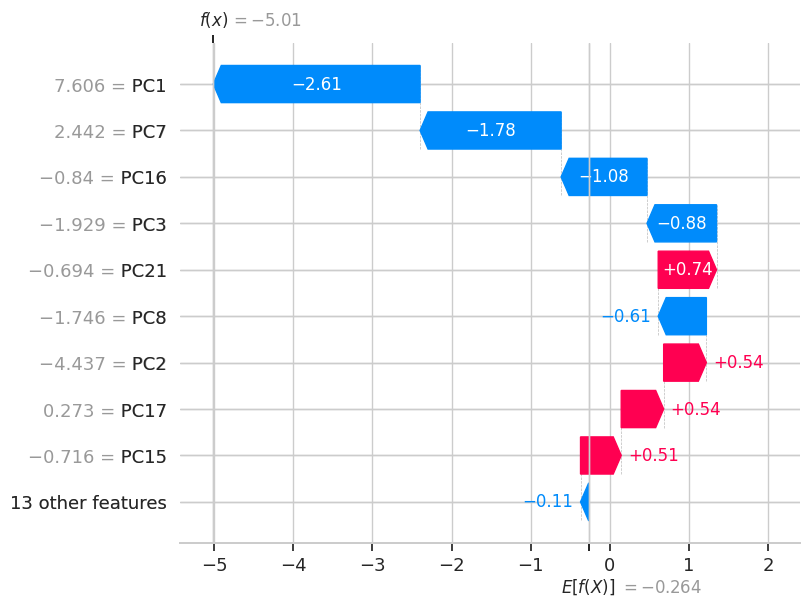

In [ ]:
#calling function

plot_shap_waterfall(
    model=best_5year_model,
    X_test=X_test,
    sample_index=10
)


SHAP analysis was used to interpret the best-performing tuned model. Results show that the first principal component (PC1), followed by PC3 and PC10, had the strongest influence on bankruptcy prediction. Beeswarm and waterfall plots confirm both global and local interpretability.

# Identifies the best-performing models based on AUC for Baseline models.

In [ ]:
def identify_best_models(baseline_results):
    """
    Identifies the best-performing model(s) based on AUC.

    This function:
    1) Selects the best model per forecasting horizon (1–5 years)
       using highest AUC.
    2) Computes the overall best model across all years using
       mean AUC.

    Parameters:
    baseline_results : pd.DataFrame
        DataFrame containing model evaluation results with columns:
        ['Dataset', 'Model', 'Accuracy', 'Precision', 'Recall',
         'F1-Score', 'AUC']

    Returns:
    best_per_year : pd.DataFrame
        Best model for each forecasting horizon

    overall_best : pd.Series
        Overall best model across all years (mean AUC)
    """

    # Best model per year
    best_per_year = (
        baseline_results
        .loc[baseline_results.groupby("Dataset")["AUC"].idxmax()]
        .sort_values("Dataset")
        .reset_index(drop=True)
    )

    # Overall best model across all years
    overall_best = (
        baseline_results
        .groupby("Model")["AUC"]
        .mean()
        .sort_values(ascending=False)
    )

    print("\n Best Model per Forecasting Horizon (Based on AUC):\n")
    print(best_per_year[["Dataset", "Model", "AUC"]])

    print("\n Overall Best Model Across All Years (Mean AUC):\n")
    print(overall_best)

    print(
        f"\n Final Conclusion:\n"
        f"The overall best-performing model is "
        f"'{overall_best.idxmax()}' "
        f"with a mean AUC of {overall_best.max():.3f}."
    )

    return best_per_year, overall_best


# FUNCTION CALL (FINAL STEP)
best_models_per_year, overall_best_model = identify_best_models(baseline_results)



 Best Model per Forecasting Horizon (Based on AUC):

  Dataset     Model       AUC
0   1year  CatBoost  0.995657
1   2year   XGBoost  0.993010
2   3year   XGBoost  0.990499
3   4year   XGBoost  0.987431
4   5year   XGBoost  0.989761

 Overall Best Model Across All Years (Mean AUC):

Model
XGBoost     0.990914
CatBoost    0.990533
LightGBM    0.979081
Name: AUC, dtype: float64

 Final Conclusion:
The overall best-performing model is 'XGBoost' with a mean AUC of 0.991.


# Identifies the best-performing models based on AUC for Tunned models.

In [ ]:
def identify_best_models(tuned_results):
    """
    Identifies the best-performing model(s) based on AUC.

    This function:
    1) Selects the best model per forecasting horizon (1–5 years)
       using highest AUC.
    2) Computes the overall best model across all years using
       mean AUC.

    Parameters:
    tuned_results : pd.DataFrame
        DataFrame containing model evaluation results with columns:
        ['Dataset', 'Model', 'Accuracy', 'Precision', 'Recall',
         'F1-Score', 'AUC']

    Returns:
    best_per_year : pd.DataFrame
        Best model for each forecasting horizon

    overall_best : pd.Series
        Overall best model across all years (mean AUC)
    """

    # Best model per year
    best_per_year = (
        tuned_results
        .loc[tuned_results.groupby("Dataset")["AUC"].idxmax()]
        .sort_values("Dataset")
        .reset_index(drop=True)
    )

    # Overall best model across all years
    overall_best = (
        tuned_results
        .groupby("Model")["AUC"]
        .mean()
        .sort_values(ascending=False)
    )

    print("\n Best Model per Forecasting Horizon (Based on AUC):\n")
    print(best_per_year[["Dataset", "Model", "AUC"]])

    print("\n Overall Best Model Across All Years (Mean AUC):\n")
    print(overall_best)

    print(
        f"\n Final Conclusion:\n"
        f"The overall best-performing model is "
        f"'{overall_best.idxmax()}' "
        f"with a mean AUC of {overall_best.max():.3f}."
    )

    return best_per_year, overall_best


# FUNCTION CALL (FINAL STEP)
best_models_per_year, overall_best_model = identify_best_models(tuned_results)



 Best Model per Forecasting Horizon (Based on AUC):

  Dataset           Model       AUC
0   1year  CatBoost_Tuned  0.993457
1   2year  CatBoost_Tuned  0.984353
2   3year  LightGBM_Tuned  0.983324
3   4year  LightGBM_Tuned  0.975203
4   5year  CatBoost_Tuned  0.986725

 Overall Best Model Across All Years (Mean AUC):

Model
LightGBM_Tuned    0.984096
CatBoost_Tuned    0.983763
XGBoost_Tuned     0.962299
Name: AUC, dtype: float64

 Final Conclusion:
The overall best-performing model is 'LightGBM_Tuned' with a mean AUC of 0.984.


After hyperparameter tuning, no single model dominated all forecasting horizons. CatBoost achieved the highest AUC for short-term (1–2 year) and long-term (5-year) bankruptcy prediction, while LightGBM performed best for mid-term horizons (3–4 years). When considering overall performance across all five years, LightGBM_Tuned achieved the highest mean AUC (0.984), indicating superior stability and generalisation. Therefore, LightGBM_Tuned is identified as the overall best-performing tuned model, while CatBoost_Tuned is particularly effective for extreme short- and long-horizon prediction.